<h1 style="color:#2E86C1; text-align:center;">
xAI Analysis of TimeLDM for Time Series Generation
</h1>

<p style="text-align:center; font-size:18px; color:#555;">
Iliass Khoutaibi · Théo Basséras
</p>

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import tqdm
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.manifold import TSNE
from scipy.stats import gaussian_kde
from scipy.linalg import sqrtm
from torch.nn.utils import spectral_norm

import warnings
warnings.filterwarnings("ignore")

In [2]:
torch.manual_seed(42)
np.random.seed(42)

# Are you using Cuda ? 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## <ins style = "color : orange">Vizualising the generated waves.</ins>

We define here important vizualisation functions, which plot detailed comparisons between the generative processes, frequency analysis of the generated samples, TSNE domain comparison and finally KDE comparison. 

In [3]:
def plot_detailed_comparison(
    original,
    vae_recon,
    ldm_gen,
    algorithm_name="Algorithm",
    num_samples=3,
):
    original = original.cpu()
    vae_recon = vae_recon.detach().cpu() if hasattr(vae_recon, "detach") else torch.tensor(vae_recon).cpu()
    ldm_gen = ldm_gen.cpu() if hasattr(ldm_gen, "cpu") else torch.tensor(ldm_gen).cpu()

    dim = original.shape[2]

    fig, axes = plt.subplots(num_samples, dim, figsize=(4 * dim, 3 * num_samples))
    fig.suptitle(f"{algorithm_name} - Time Series Comparison", fontsize=16, y=1.02)

    for i in range(num_samples):
        for d in range(dim):
            ax = axes[i, d]

            ax.plot(original[i, :, d], label="Original", linewidth=2)
            ax.plot(vae_recon[i, :, d], "--", label="VAE Recon", linewidth=2)
            ax.plot(ldm_gen[i, :, d], ":", label="Generated", linewidth=2)

            ax.set_title(f"Sample {i+1}, Dim {d+1}")
            ax.set_ylim(-1.5, 1.5)
            ax.grid(alpha=0.3)

            if i == 0 and d == 0:
                ax.legend()

    plt.tight_layout()
    plt.show()

In [4]:
def plot_frequency_analysis(
    original,
    vae_recon,
    ldm_gen,
    algorithm_name="Algorithm",
    num_samples=3,
):
    original = original.cpu()
    vae_recon = vae_recon.detach().cpu() if hasattr(vae_recon, "detach") else torch.tensor(vae_recon).cpu()
    ldm_gen = ldm_gen.cpu() if hasattr(ldm_gen, "cpu") else torch.tensor(ldm_gen).cpu()

    dim = original.shape[2]

    fig, axes = plt.subplots(num_samples, dim, figsize=(4 * dim, 3 * num_samples))
    fig.suptitle(f"{algorithm_name} - FFT Magnitude", fontsize=16, y=1.02)

    for i in range(num_samples):
        for d in range(dim):
            ax = axes[i, d]

            fft_orig = torch.fft.rfft(original[i, :, d]).abs().numpy()
            fft_vae = torch.fft.rfft(vae_recon[i, :, d]).abs().numpy()
            fft_ldm = torch.fft.rfft(ldm_gen[i, :, d]).abs().numpy()

            freq = np.arange(len(fft_orig))

            ax.plot(freq, fft_orig, label="Original")
            ax.plot(freq, fft_vae, "--", label="VAE")
            ax.plot(freq, fft_ldm, ":", label="LDM")

            ax.set_title(f"S{i+1}, D{d+1}")
            ax.grid(alpha=0.3)

            if i == 0 and d == 0:
                ax.legend()

    plt.tight_layout()
    plt.show()

In [5]:
def plot_tsne_comparison(real, synth, algorithm_name="Algorithm"):
    real = real.cpu().numpy() if hasattr(real, "cpu") else np.array(real)
    synth = synth.cpu().numpy() if hasattr(synth, "cpu") else np.array(synth)

    n = min(500, len(real), len(synth))

    real_flat = real[:n].reshape(n, -1)
    synth_flat = synth[:n].reshape(n, -1)

    X = np.vstack([real_flat, synth_flat])

    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_emb = tsne.fit_transform(X)

    plt.figure(figsize=(8, 6))

    plt.scatter(X_emb[:n, 0], X_emb[:n, 1], s=10, alpha=0.6, label="Real")
    plt.scatter(X_emb[n:, 0], X_emb[n:, 1], s=10, alpha=0.6, label="Generated")

    plt.title(f"{algorithm_name} - t-SNE")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [6]:
def plot_kde_comparison(real, synth, algorithm_name="Algorithm"):
    real = real.cpu().numpy() if hasattr(real, "cpu") else np.array(real)
    synth = synth.cpu().numpy() if hasattr(synth, "cpu") else np.array(synth)

    x = np.linspace(-1.5, 1.5, 200)

    kde_real = gaussian_kde(real[:, :, 0].flatten())
    kde_synth = gaussian_kde(synth[:, :, 0].flatten())

    plt.figure(figsize=(8, 6))
    plt.plot(x, kde_real(x), label="Real")
    plt.plot(x, kde_synth(x), "--", label="Generated")

    plt.title(f"{algorithm_name} - KDE (dim 0)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

## <ins style = "color : orange">The dataset</ins>

We construct a synthetic multivariate time series dataset composed of sine waves with structured frequency variations.

Each sample is a multivariate time series of shape:

$$
x \in \mathbb{R}^{T \times D}
$$

- $T$: sequence length (e.g., $T = 24$)  
- $D$: number of dimensions (e.g., $D = 5$)

Each dimension corresponds to a sine wave:

$$
x_t^{(j)} = \sin(f_j \cdot t + \phi_j)
$$

- $f_j$: frequency of dimension $j$  
- $\phi_j \sim \mathcal{U}(0, 2\pi)$: random phase  

Each dimension has its own frequency distribution:

$$
f_j \sim \mathcal{N}(\mu_j, \sigma^2)
$$

with:

- $\mu = [0.3, 0.6, 3.8, 1.2, 2.4]$
- $\sigma = 0.02$

Frequencies are clipped to a valid range:

$$
f_j \in [0.1, 5.0]
$$


This dataset is designed to: Evaluate the model's ability to capture **periodic patterns**, test whether the model preserves **frequency-specific structure** and enable **interpretability analysis** (e.g., Sobol, counterfactuals)

In particular, the known ground-truth frequencies make it possible to assess whether the model correctly encodes and reproduces spectral properties.

In [7]:
FREQUENCIES = [0.3, 0.6, 3.8, 1.2, 2.4]

In [8]:
def _generate_single_sine_sample(freqs, seq_len):
    """
    Generate one multivariate sine sample.

    freqs: list of frequencies (dim,)
    returns: (seq_len, dim)
    """
    dim = len(freqs)
    sample = []

    for j in range(dim):
        freq = freqs[j]
        phase = np.random.uniform(0, 2 * np.pi)

        t = np.arange(seq_len)
        signal = np.sin(freq * t + phase)

        sample.append(signal)

    return np.array(sample).T  

In [9]:
def generate_sine_data_with_embedding(
    n_samples: int = 10000,
    seq_len: int = 24,
    dim: int = 5,
):
    """
    Structured dataset:
    Each dimension has its own frequency distribution.
    """

    freq_distributions = [
        {"mean": FREQUENCIES[0], "std": 0.02},
        {"mean": FREQUENCIES[1], "std": 0.02},
        {"mean": FREQUENCIES[2], "std": 0.02},
        {"mean": FREQUENCIES[3], "std": 0.02},
        {"mean": FREQUENCIES[4], "std": 0.02},
    ]

    data = []

    for _ in range(n_samples):
        freqs = []

        for j in range(dim):
            f = np.random.normal(
                freq_distributions[j]["mean"],
                freq_distributions[j]["std"],
            )
            f = np.clip(f, 0.1, 5.0)
            freqs.append(f)

        sample = _generate_single_sine_sample(freqs, seq_len)
        data.append(sample)

    return torch.tensor(np.array(data), dtype=torch.float32)

In [10]:
def generate_sine_data_fixed(
    n_samples: int = 10000,
    seq_len: int = 24,
    dim: int = 5,
):
    """
    Each dimension has a fixed frequency.
    Only phase varies.
    """
    data = []

    for _ in range(n_samples):
        sample = _generate_single_sine_sample(FREQUENCIES[:dim], seq_len)
        data.append(sample)

    return torch.tensor(np.array(data), dtype=torch.float32)

In [11]:
def generate_sine_data_varied(
    n_samples: int = 10000,
    seq_len: int = 24,
    dim: int = 5,
):
    """
    Small perturbations around base frequencies.
    """
    data = []

    for _ in range(n_samples):
        freqs = []

        for j in range(dim):
            f = FREQUENCIES[j] + np.random.uniform(-0.05, 0.05)
            f = np.clip(f, 0.1, 5.0)
            freqs.append(f)

        sample = _generate_single_sine_sample(freqs, seq_len)
        data.append(sample)

    return torch.tensor(np.array(data), dtype=torch.float32)

In [12]:
print("Generating dataset...")

DATA = generate_sine_data_with_embedding(
    n_samples=10000,
    seq_len=24,
    dim=5,
)

print("Data shape:", DATA.shape)

Generating dataset...
Data shape: torch.Size([10000, 24, 5])


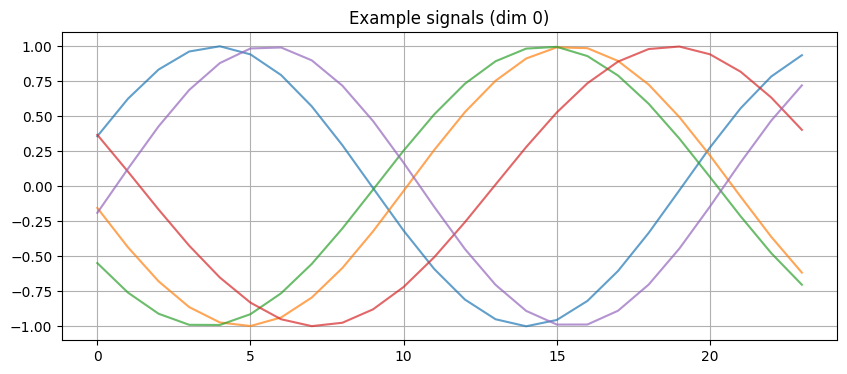

In [13]:
plt.figure(figsize=(10, 4))

for i in range(5):
    plt.plot(DATA[i, :, 0].cpu(), alpha=0.7)

plt.title("Example signals (dim 0)")
plt.grid()
plt.show()

## <ins style = "color : orange">The metrics.</ins> 

We evaluate the quality of the generated time series using both statistical and task-oriented metrics.

### 1. Context-FID Score

The Context-FID score measures the distance between feature distributions of real and generated data.

Feature vectors include statistics such as mean, standard deviation, skewness, kurtosis, autocorrelation, and frequency components.

$$
\text{FID} = \|\mu_r - \mu_g\|^2 + \mathrm{Tr}\left(\Sigma_r + \Sigma_g - 2(\Sigma_r \Sigma_g)^{1/2}\right)
$$

- $\mu_r, \Sigma_r$: mean and covariance of real data features  
- $\mu_g, \Sigma_g$: mean and covariance of generated data features  

**Interpretation:**
- Lower is better  
- Measures global distribution alignment  


### 2. Correlational Score

This metric evaluates how well cross-variable dependencies are preserved.

$$
\text{CorrScore} = \mathbb{E}\left[ \| C_r - C_g \|_1 \right]
$$

- $C_r$, $C_g$: correlation matrices of real and generated data  

**Interpretation:**
- Lower is better  
- Measures preservation of inter-variable relationships  


### 3. Discriminative Score

A classifier is trained to distinguish real from generated sequences.

$$
\text{Score} = \max(0, \text{Accuracy} - 0.5)
$$

**Interpretation:**
- Close to 0 → generated data is indistinguishable from real  
- Higher → easier to distinguish → worse generation  


### 4. Predictive Score (TSTR)

Train on Synthetic, Test on Real.

A model trained on generated data predicts future time steps and is evaluated on real data:

$$
\text{MSE} = \frac{1}{N} \sum_{i=1}^{N} \| \hat{x}_i - x_i \|_2^2
$$

- $\hat{x}_i$: predicted sequence  
- $x_i$: ground truth sequence  

**Interpretation:**
- Lower is better  
- Measures usefulness of generated data for downstream tasks

In [14]:
def compute_context_fid_score(real, synth):
    """Context-FID score using statistical features"""

    def extract_features(data):
        data = data.detach().cpu() if torch.is_tensor(data) else torch.tensor(data, dtype=torch.float32)
        features = []

        for i in range(len(data)):
            sample = data[i]   # shape: (seq_len, dim)

            mean = sample.mean(dim=0)
            std = sample.std(dim=0) + 1e-8

            centered = sample - mean

            skew = (centered ** 3).mean(dim=0) / (std ** 3)
            kurt = (centered ** 4).mean(dim=0) / (std ** 4)

            min_val = sample.min(dim=0).values
            max_val = sample.max(dim=0).values
            range_val = max_val - min_val

            autocorr = []
            for lag in range(1, 4):
                if lag < len(sample):
                    ac = (sample[lag:] * sample[:-lag]).mean(dim=0)
                else:
                    ac = torch.zeros_like(mean)
                autocorr.append(ac)

            fft_vals = torch.fft.rfft(sample, dim=0)
            fft_magnitudes = fft_vals.abs()
            dominant_freqs = fft_magnitudes.topk(k=min(3, fft_magnitudes.shape[0]), dim=0).values.mean(dim=0)

            feature = torch.cat([
                mean, std, skew, kurt,
                min_val, max_val, range_val,
                *autocorr,
                dominant_freqs
            ])

            feature = torch.nan_to_num(feature, nan=0.0, posinf=1e6, neginf=-1e6)
            features.append(feature)

        return torch.stack(features)

    real_feat = extract_features(real)
    synth_feat = extract_features(synth)

    mu_real = real_feat.mean(dim=0)
    mu_synth = synth_feat.mean(dim=0)

    real_centered = real_feat - mu_real
    synth_centered = synth_feat - mu_synth

    cov_real = (real_centered.T @ real_centered) / max(len(real_feat) - 1, 1)
    cov_synth = (synth_centered.T @ synth_centered) / max(len(synth_feat) - 1, 1)

    eps = 1e-6
    cov_real += eps * torch.eye(cov_real.size(0))
    cov_synth += eps * torch.eye(cov_synth.size(0))

    mu_real_np = mu_real.detach().cpu().numpy()
    mu_synth_np = mu_synth.detach().cpu().numpy()
    cov_real_np = cov_real.detach().cpu().numpy()
    cov_synth_np = cov_synth.detach().cpu().numpy()

    diff = mu_real_np - mu_synth_np
    diff_norm = diff @ diff

    covmean = sqrtm(cov_real_np @ cov_synth_np)

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    trace_term = np.trace(cov_real_np + cov_synth_np - 2 * covmean)

    fid = diff_norm + trace_term
    return fid

def compute_correlational_score(real, synth):
    """Correlational score"""
    def compute_cross_correlation(data):
        data = data.cpu() if hasattr(data, 'cpu') else torch.tensor(data)
        batch_size, seq_len, dim = data.shape
        corr_mats = []
        for i in range(min(batch_size, 500)):
            sample = data[i]
            sample_normalized = (sample - sample.mean(dim=0)) / (sample.std(dim=0) + 1e-8)
            corr = torch.corrcoef(sample_normalized.T)
            corr_mats.append(corr)
        return torch.stack(corr_mats).mean(dim=0)

    real_corr = compute_cross_correlation(real)
    synth_corr = compute_cross_correlation(synth)
    return torch.abs(real_corr - synth_corr).mean().item()

def compute_discriminative_score(real, synth, seq_len, input_dim, epochs=200):
    """Discriminative score"""
    class Discriminator(nn.Module):
        def __init__(self, input_dim, hidden_dim=100):
            super().__init__()
            self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True, num_layers=2)
            self.linear = nn.Linear(hidden_dim * 2, 1)
            self.sigmoid = nn.Sigmoid()

        def forward(self, x):
            out, _ = self.lstm(x)
            out = out[:, -1, :]
            return self.sigmoid(self.linear(out))

    real = real.cpu() if hasattr(real, 'cpu') else torch.tensor(real)
    synth = synth.cpu() if hasattr(synth, 'cpu') else torch.tensor(synth)

    X = torch.cat([real, synth], dim=0)
    y = torch.cat([torch.ones(len(real)), torch.zeros(len(synth))], dim=0)

    idx = torch.randperm(len(X))
    X, y = X[idx], y[idx]

    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    model = Discriminator(input_dim)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(epochs):
        model.train()
        pred = model(X_train).squeeze()
        loss = F.binary_cross_entropy(pred, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        pred = model(X_test).squeeze()
        accuracy = ((pred > 0.5).float() == y_test).float().mean()

    return 1 - accuracy.item()

def compute_predictive_score(real, synth, seq_len, input_dim, pred_len=5, epochs=100):
    """Predictive score using TSTR"""
    class Predictor(nn.Module):
        def __init__(self, input_dim, hidden_dim=100):
            super().__init__()
            self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, num_layers=2)
            self.linear = nn.Linear(hidden_dim, input_dim)

        def forward(self, x):
            out, _ = self.lstm(x)
            return self.linear(out[:, -pred_len:, :])

    synth = synth.cpu() if hasattr(synth, 'cpu') else torch.tensor(synth)
    real = real.cpu() if hasattr(real, 'cpu') else torch.tensor(real)

    X_synth = synth[:, :-pred_len, :]
    y_synth = synth[:, -pred_len:, :]
    X_real = real[:, :-pred_len, :]
    y_real = real[:, -pred_len:, :]

    predictor = Predictor(input_dim)
    optimizer = optim.Adam(predictor.parameters(), lr=1e-3)

    for epoch in range(epochs):
        predictor.train()
        pred = predictor(X_synth)
        loss = F.mse_loss(pred, y_synth)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    predictor.eval()
    with torch.no_grad():
        pred = predictor(X_real)
        mse = F.mse_loss(pred, y_real)

    return mse.item()

def evaluate_all_metrics(real, synth, seq_len, input_dim, algorithm_name="Algorithm"):
    """Compute all evaluation metrics"""
    print(f"\n{'='*50}")
    print(f"{algorithm_name} - Evaluation Metrics")
    print('='*50)

    real_cpu = real.cpu() if hasattr(real, 'cpu') else torch.tensor(real)
    synth_cpu = synth.cpu() if hasattr(synth, 'cpu') else torch.tensor(synth)

    n_samples = min(1000, len(real_cpu), len(synth_cpu))
    real_subset = real_cpu[:n_samples]
    synth_subset = synth_cpu[:n_samples]

    # FID Score
    fid = compute_context_fid_score(real_subset, synth_subset)
    print(f"Context-FID Score: {fid:.4f}")

    # Correlational Score
    corr = compute_correlational_score(real_subset, synth_subset)
    print(f"Correlational Score: {corr:.4f}")

    # Discriminative Score
    disc = compute_discriminative_score(real_subset, synth_subset, seq_len, input_dim)
    print(f"Discriminative Score: {disc:.4f}")

    # Predictive Score
    pred = compute_predictive_score(real_subset, synth_subset, seq_len, input_dim)
    print(f"Predictive Score: {pred:.4f}")

    return {
        'fid': fid,
        'correlational': corr,
        'discriminative': disc,
        'predictive': pred
    }

## <ins style = "color : orange"> The first algorithm implementation. </ins>

### Stage 1 — Variational Autoencoder

Given an input time series $x$, the encoder produces a latent distribution:

$$
\mu, \sigma = E_\phi(x)
$$

A latent sample is obtained using the reparameterization trick:

$$
z_0 = \mu + \sigma \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)
$$

The decoder reconstructs the signal:

$$
\hat{x} = D_\xi(z_0)
$$

The VAE is trained with a combination of reconstruction and regularization losses:

$$
\mathcal{L}_{\text{VAE}} = \lambda_1 \|x - \hat{x}\|_2^2 + \lambda_2 \|x - \hat{x}\|_1 + \lambda_3 \|\text{FFT}(x) - \text{FFT}(\hat{x})\|_2^2 + \beta \, \text{KL}(q_\phi(z|x) \| \mathcal{N}(0, I))
$$

### Stage 2 — Latent Diffusion Model

Once the VAE is trained, its parameters are frozen. The diffusion model is then trained on latent variables.

A noisy latent is constructed as:

$$
z_t = \sqrt{\bar{\alpha}_t} \, z_0 + \sqrt{1 - \bar{\alpha}_t} \, \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)
$$

The model learns to predict the noise using a neural network $\epsilon_\theta$:

$$
\mathcal{L}_{\text{diff}} = \mathbb{E}_{t, z_0, \epsilon} \left[ \|\epsilon - \epsilon_\theta(z_t, t)\|_2^2 \right]
$$

### Sampling

Generation starts from pure Gaussian noise:

$$
z_T \sim \mathcal{N}(0, I)
$$

The model iteratively denoises:

$$
z_{t-1} = \text{reverse\_step}(z_t, \epsilon_\theta(z_t, t), t)
$$

After the final step, the latent is decoded:

$$
\hat{x} = D_\xi(z_0)
$$

This procedure produces a synthetic time series with similar properties to the training data.

First we define a transformer VAE class.

In [15]:
class Algorithm_1_TransformerVAE(nn.Module):
    def __init__(
        self,
        input_dim: int = 5,
        latent_dim: int = 16,
        n_heads: int = 2,
        seq_len: int = 24,
        layers: tuple[int, int] = (1, 2),
    ):
        super().__init__()

        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.seq_len = seq_len

        self.embed = nn.Sequential(
            nn.Conv1d(input_dim, latent_dim, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(latent_dim, latent_dim, kernel_size=3, padding=1),
        )

        self.pos_enc = nn.Parameter(torch.randn(1, seq_len, latent_dim))

        enc_layer = nn.TransformerEncoderLayer(
            d_model=latent_dim,
            nhead=n_heads,
            batch_first=True,
            dropout=0.0,
        )
        self.encoder_mu = nn.TransformerEncoder(enc_layer, num_layers=layers[0])
        self.encoder_log_var = nn.TransformerEncoder(enc_layer, num_layers=layers[0])

        self.dec_embed = nn.Sequential(
            nn.Conv1d(latent_dim, latent_dim, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(latent_dim, latent_dim, kernel_size=3, padding=1),
        )

        self.dec_pos_enc = nn.Parameter(torch.randn(1, seq_len, latent_dim))

        dec_layer = nn.TransformerDecoderLayer(
            d_model=latent_dim,
            nhead=n_heads,
            batch_first=True,
            dropout=0.0,
        )
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=layers[1])
        self.output_proj = nn.Linear(latent_dim, input_dim)

    def encode(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """
        x: (B, T, input_dim)
        returns:
            mu:      (B, T, latent_dim)
            log_var: (B, T, latent_dim)
        """
        e = self.embed(x.permute(0, 2, 1)).permute(0, 2, 1)
        e = e + self.pos_enc

        mu = self.encoder_mu(e)
        log_var = self.encoder_log_var(e)
        log_var = torch.clamp(log_var, min=-10.0, max=10.0)

        return mu, log_var

    def reparameterize(self, mu: torch.Tensor, log_var: torch.Tensor) -> torch.Tensor:
        """
        This is the reparemtrization trick of the VAE
        """
        sigma = torch.exp(0.5 * log_var)
        eps = torch.randn_like(sigma)
        return mu + eps * sigma

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        """
        z: (B, T, latent_dim)
        returns:
            recon: (B, T, input_dim)
        """
        z_emb = self.dec_embed(z.permute(0, 2, 1)).permute(0, 2, 1)
        z_emb = z_emb + self.dec_pos_enc

        recon = self.decoder(z_emb, z)
        return self.output_proj(recon)
    
    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Forwarding in the VAE
        """
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        recon = self.decode(z)
        return recon, mu, log_var

We then define the Latent diffusion model class.

In [16]:
class Algorithm_1_LatentDiffusion(nn.Module):
    def __init__(
        self,
        latent_dim: int = 16,
        seq_len: int = 24,
        hidden_dim: int = 1024,
    ):
        super().__init__()

        self.latent_dim = latent_dim
        self.seq_len = seq_len
        self.hidden_dim = hidden_dim

        self.input_proj = nn.Linear(latent_dim * seq_len, hidden_dim)

        self.time_embed = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim * seq_len),
        )
    
    def sinusoidal_embedding(self, t: torch.Tensor, dim: int) -> torch.Tensor:
        """
        t:   (B,)
        out: (B, dim)
        """
        half_dim = dim // 2

        freqs = torch.exp(
            -torch.arange(half_dim, device=t.device).float()
            * (np.log(10000) / (half_dim - 1))
        )

        args = t[:, None] * freqs[None, :]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

        if dim % 2 == 1:
            emb = torch.cat([emb, torch.zeros_like(emb[:, :1])], dim=-1)

        return emb
    
    def forward(self, z_t: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        z_t: (B, T, latent_dim)
        t:   (B,)
        """
        batch_size = z_t.size(0)

        z_flat = z_t.reshape(batch_size, -1)
        z_proj = self.input_proj(z_flat)

        t_emb = self.sinusoidal_embedding(t, self.hidden_dim)
        t_proj = self.time_embed(t_emb)

        h = z_proj + t_proj
        out = self.net(h)

        return out.reshape(batch_size, self.seq_len, self.latent_dim)

We instantiate both the VAE and the diffusion model.

In [17]:
vae_model = Algorithm_1_TransformerVAE(
    input_dim=5,
    latent_dim=16,
    n_heads=2,
    seq_len=24,
    layers=(1, 2),
).to(device)

ldm_model = Algorithm_1_LatentDiffusion(
    latent_dim=16,
    seq_len=24,
    hidden_dim=1024,
).to(device)

Here we define the loss used in the VAE and in the diffusion model.

In [18]:
def algorithm1_vae_reconstruction_loss(x: torch.Tensor, recon_x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Computes:
        - L2 reconstruction loss
        - L1 reconstruction loss
        - FFT magnitude loss
        - total reconstruction loss

    x, recon_x: (B, T, D)
    """
    dim = x.shape[2]

    l2_loss_dim = 0.0
    l1_loss_dim = 0.0
    fft_loss_dim = 0.0

    for d in range(dim):
        x_d = x[:, :, d]
        recon_d = recon_x[:, :, d]

        l2_loss_dim += F.mse_loss(recon_d, x_d)
        l1_loss_dim += F.l1_loss(recon_d, x_d)

        fft_x = torch.fft.rfft(x_d, dim=1)
        fft_recon = torch.fft.rfft(recon_d, dim=1)
        fft_loss_dim += F.mse_loss(fft_x.abs(), fft_recon.abs())

    l2_loss = l2_loss_dim / dim
    l1_loss = l1_loss_dim / dim
    fft_loss = fft_loss_dim / dim

    recon_loss = l1_loss + l2_loss + fft_loss
    return recon_loss, l1_loss, l2_loss, fft_loss

In [19]:
def algorithm1_vae_kl_loss(mu: torch.Tensor, log_var: torch.Tensor) -> torch.Tensor:
    """
    mu, log_var: (B, T, latent_dim)
    """
    return torch.mean(
        -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp(), dim=(-1, -2))
    )

We define below the VAE training step.

In [20]:
def algorithm1_vae_train_step(
    model: torch.nn.Module,
    x: torch.Tensor,
    optimizer: torch.optim.Optimizer,
    beta: float,
) -> dict:
    model.train()

    mu, log_var = model.encode(x)
    z = model.reparameterize(mu, log_var)
    recon_x = model.decode(z)

    recon_loss, l1_loss, l2_loss, fft_loss = algorithm1_vae_reconstruction_loss(x, recon_x)
    kl_loss = algorithm1_vae_kl_loss(mu, log_var)

    loss = recon_loss + beta * kl_loss

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    return {
        "loss": loss.item(),
        "recon_loss": recon_loss.item(),
        "l1_loss": l1_loss.item(),
        "l2_loss": l2_loss.item(),
        "fft_loss": fft_loss.item(),
        "kl_loss": kl_loss.item(),
    }

We define below the training loop of the VAE.

In [21]:
def train_algorithm1_vae(
    model,
    data,
    epochs: int = 50,
    batch_size: int = 1024,
    beta_max: float = 1.0,
    lr: float = 1e-3,
):
    optimizer = optim.Adam(model.parameters(), lr=lr)

    beta = 0.0
    beta_inc = beta_max / epochs

    for epoch in tqdm(range(epochs), desc="Algorithm 1 - Training VAE"):
        perm = torch.randperm(len(data))

        epoch_loss = 0.0
        epoch_recon = 0.0
        epoch_kl = 0.0
        n_batches = 0

        for i in range(0, len(data), batch_size):
            idx = perm[i:i + batch_size]
            x = data[idx].to(device)

            stats = algorithm1_vae_train_step(
                model=model,
                x=x,
                optimizer=optimizer,
                beta=beta,
            )

            epoch_loss += stats["loss"]
            epoch_recon += stats["recon_loss"]
            epoch_kl += stats["kl_loss"]
            n_batches += 1

        beta = min(beta + beta_inc, beta_max)

        print(
            f"Epoch {epoch + 1:03d} | "
            f"loss={epoch_loss / n_batches:.4f} | "
            f"recon={epoch_recon / n_batches:.4f} | "
            f"kl={epoch_kl / n_batches:.4f} | "
            f"beta={beta:.4f}"
        )

    return model

For the diffusion model training, since we encode the waves using the VAE's encoder, let's write a function the does so and saves them in a table to be reused.

In [22]:
@torch.no_grad()
def algorithm1_precompute_latents(
    vae_model,
    data,
    batch_size: int = 1024,
):
    vae_model.eval()

    mu_list = []

    for i in range(0, len(data), batch_size):
        x_batch = data[i:i + batch_size].to(device)
        mu, _ = vae_model.encode(x_batch)
        mu_list.append(mu.cpu())

    return torch.cat(mu_list, dim=0)

We define below the latent diffusion training step.

In [23]:
def algorithm1_ldm_train_step(
    ldm_model,
    z0: torch.Tensor,
    optimizer: torch.optim.Optimizer,
    T: float = 1.0,
) -> dict:
    ldm_model.train()

    t = torch.rand(z0.size(0), device=z0.device) * T
    epsilon = torch.randn_like(z0)
    z_t = z0 + t[:, None, None] * epsilon

    pred_epsilon = ldm_model(z_t, t)
    loss = F.mse_loss(pred_epsilon, epsilon)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(ldm_model.parameters(), max_norm=1.0)
    optimizer.step()

    return {"loss": loss.item()}

We define below the latent diffusion training loop.

In [24]:
def train_algorithm1_ldm(
    ldm_model,
    vae_model,
    data,
    epochs: int = 50,
    batch_size: int = 1024,
    T: float = 1.0,
    lr: float = 1e-4,
):
    optimizer = optim.Adam(ldm_model.parameters(), lr=lr)

    mu_all = algorithm1_precompute_latents(
        vae_model=vae_model,
        data=data,
        batch_size=batch_size,
    )

    for epoch in tqdm(range(epochs), desc="Algorithm 1 - Training LDM"):
        perm = torch.randperm(len(mu_all))

        epoch_loss = 0.0
        n_batches = 0

        for i in range(0, len(mu_all), batch_size):
            idx = perm[i:i + batch_size]
            z0 = mu_all[idx].to(device)

            stats = algorithm1_ldm_train_step(
                ldm_model=ldm_model,
                z0=z0,
                optimizer=optimizer,
                T=T,
            )

            epoch_loss += stats["loss"]
            n_batches += 1

        print(f"Epoch {epoch + 1:03d} | loss={epoch_loss / n_batches:.4f}")

    return ldm_model

We train both the VAE and the latent diffusion model.

In [25]:
vae_model = train_algorithm1_vae(
    model=vae_model,
    data=DATA,
    epochs=100,
    batch_size=1024,
    beta_max=1.0,
    lr=1e-3,
)

Algorithm 1 - Training VAE:   1%|          | 1/100 [00:02<03:29,  2.12s/it]

Epoch 001 | loss=14.7926 | recon=14.7926 | kl=317.3234 | beta=0.0100


Algorithm 1 - Training VAE:   2%|▏         | 2/100 [00:03<02:16,  1.40s/it]

Epoch 002 | loss=8.2147 | recon=5.4245 | kl=279.0159 | beta=0.0200


Algorithm 1 - Training VAE:   3%|▎         | 3/100 [00:03<01:52,  1.16s/it]

...

Epoch 098 | loss=2.1143 | recon=2.1141 | kl=0.0003 | beta=0.9800


Algorithm 1 - Training VAE:  99%|█████████▉| 99/100 [01:13<00:00,  1.38it/s]

Epoch 099 | loss=2.1164 | recon=2.1159 | kl=0.0005 | beta=0.9900


Algorithm 1 - Training VAE: 100%|██████████| 100/100 [01:14<00:00,  1.35it/s]

Epoch 100 | loss=2.1102 | recon=2.1097 | kl=0.0005 | beta=1.0000


In [26]:
ldm_model = train_algorithm1_ldm(
    ldm_model=ldm_model,
    vae_model=vae_model,
    data=DATA,
    epochs=100,
    batch_size=1024,
    T=1.0,
    lr=1e-4,
)

Algorithm 1 - Training LDM:   2%|▏         | 2/100 [00:00<00:11,  8.79it/s]

Epoch 001 | loss=0.9988
Epoch 002 | loss=0.9924


Algorithm 1 - Training LDM:   4%|▍         | 4/100 [00:00<00:10,  9.02it/s]

Epoch 003 | loss=0.9781
Epoch 004 | loss=0.9654


Algorithm 1 - Training LDM:   6%|▌         | 6/100 [00:00<00:10,  9.01it/s]

...

Epoch 095 | loss=0.3589
Epoch 096 | loss=0.3488


Algorithm 1 - Training LDM:  98%|█████████▊| 98/100 [00:12<00:00,  7.55it/s]

Epoch 097 | loss=0.3491
Epoch 098 | loss=0.3526


Algorithm 1 - Training LDM: 100%|██████████| 100/100 [00:13<00:00,  7.59it/s]

Epoch 099 | loss=0.3482
Epoch 100 | loss=0.3449


We define below the sampling procedure of the latent diffusion model.

In [27]:
@torch.no_grad()
def sample_algorithm1_ldm(
    ldm_model,
    vae_model,
    num_samples: int,
    seq_len: int,
    latent_dim: int,
    device,
    T: float = 1.0,
    steps: int = 100,
):
    ldm_model.eval()
    vae_model.eval()

    z_t = torch.randn(num_samples, seq_len, latent_dim, device=device) * T
    dt = T / steps

    for i in range(steps, 0, -1):
        t_val = i * dt
        t = torch.full((num_samples,), t_val, device=device)

        epsilon_pred = ldm_model(z_t, t)
        score = -epsilon_pred / t_val

        z_t = z_t + 2.0 * t_val * score * dt

        if i > 1:
            noise_scale = torch.sqrt(torch.tensor(2.0 * t_val * dt, device=device))
            z_t = z_t + noise_scale * torch.randn_like(z_t)

    samples = vae_model.decode(z_t)
    return samples, z_t

Let us sample some sine waves.

In [28]:
samples_alg1, _ = sample_algorithm1_ldm(
    ldm_model=ldm_model,
    vae_model=vae_model,
    num_samples=256,
    seq_len=24,
    latent_dim=16,
    device=device,
    T=1.0,
    steps=100,
)
print("Generated samples shape:", samples_alg1.shape)

Generated samples shape: torch.Size([256, 24, 5])


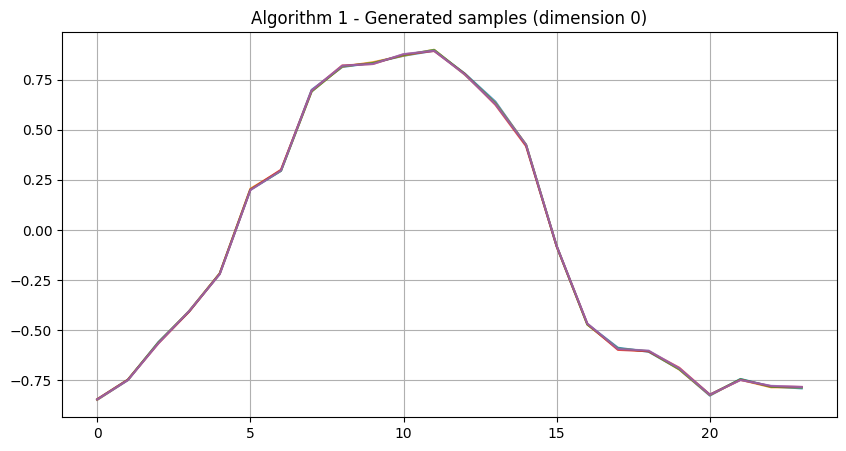

In [29]:
plt.figure(figsize=(10, 5))

for i in range(5):
    plt.plot(samples_alg1[i, :, 0].cpu().numpy(), alpha=0.8)

plt.title("Algorithm 1 - Generated samples (dimension 0)")
plt.grid()
plt.show()

Let's plot the results.

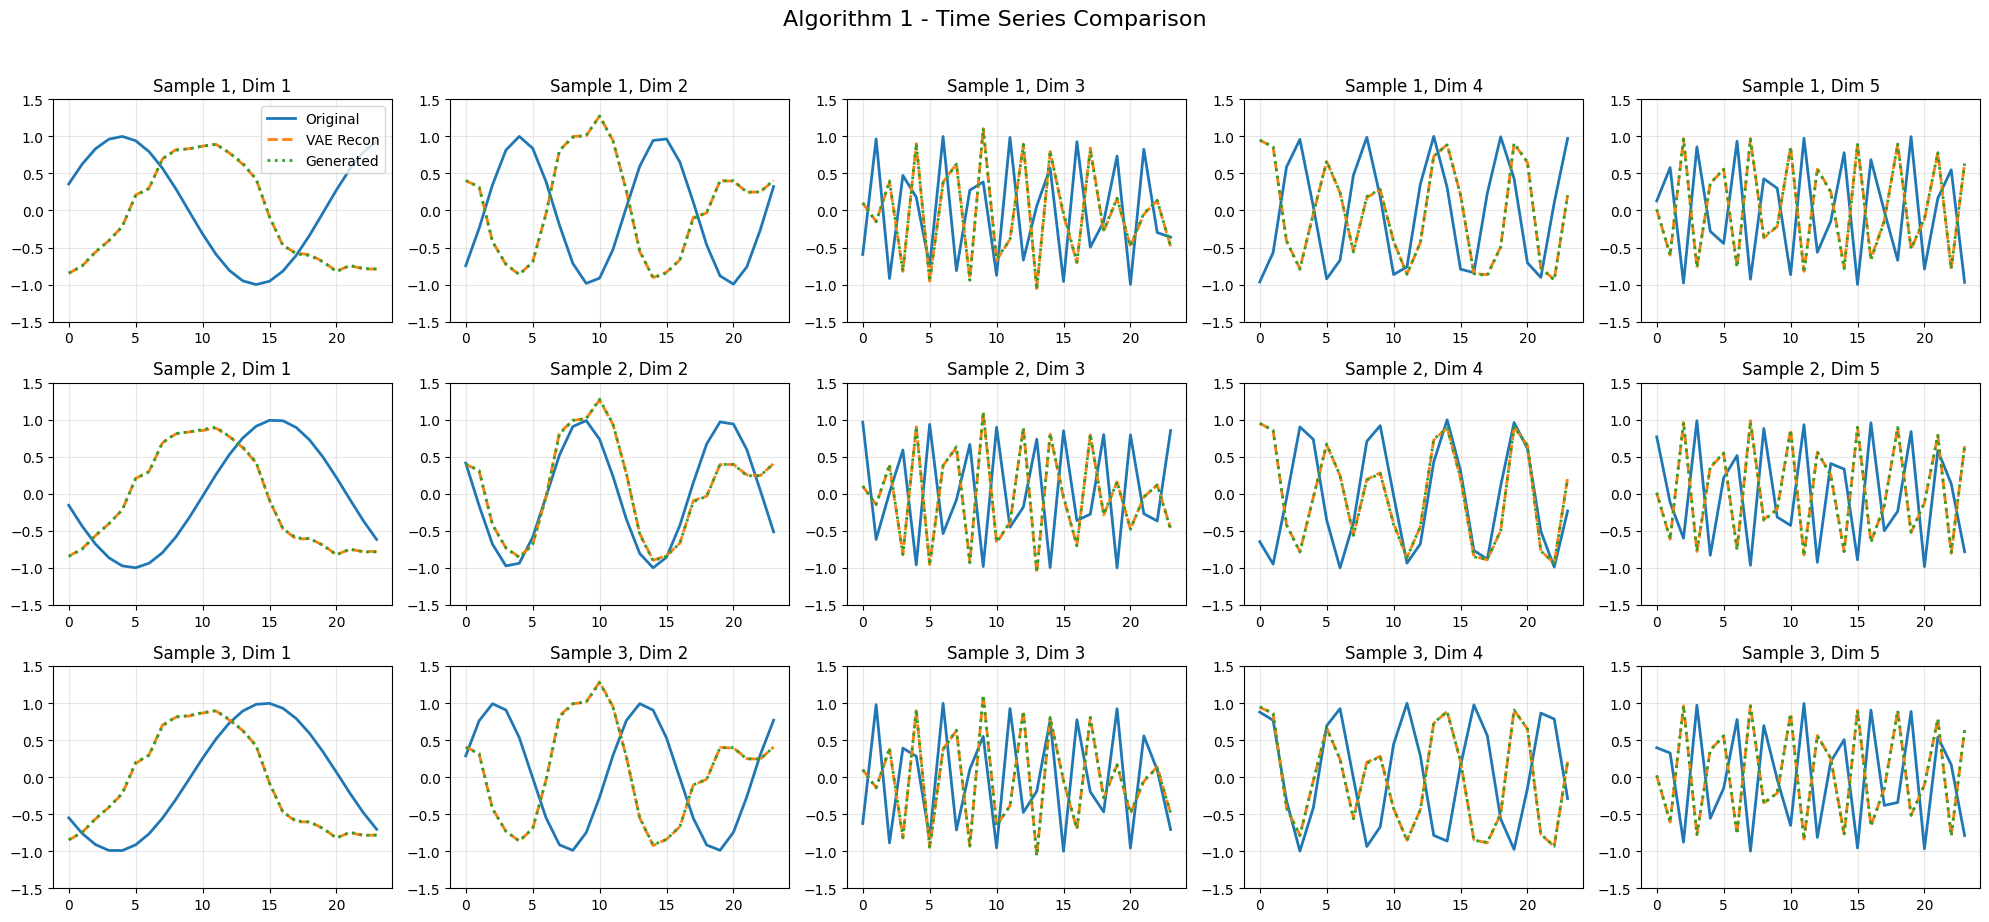

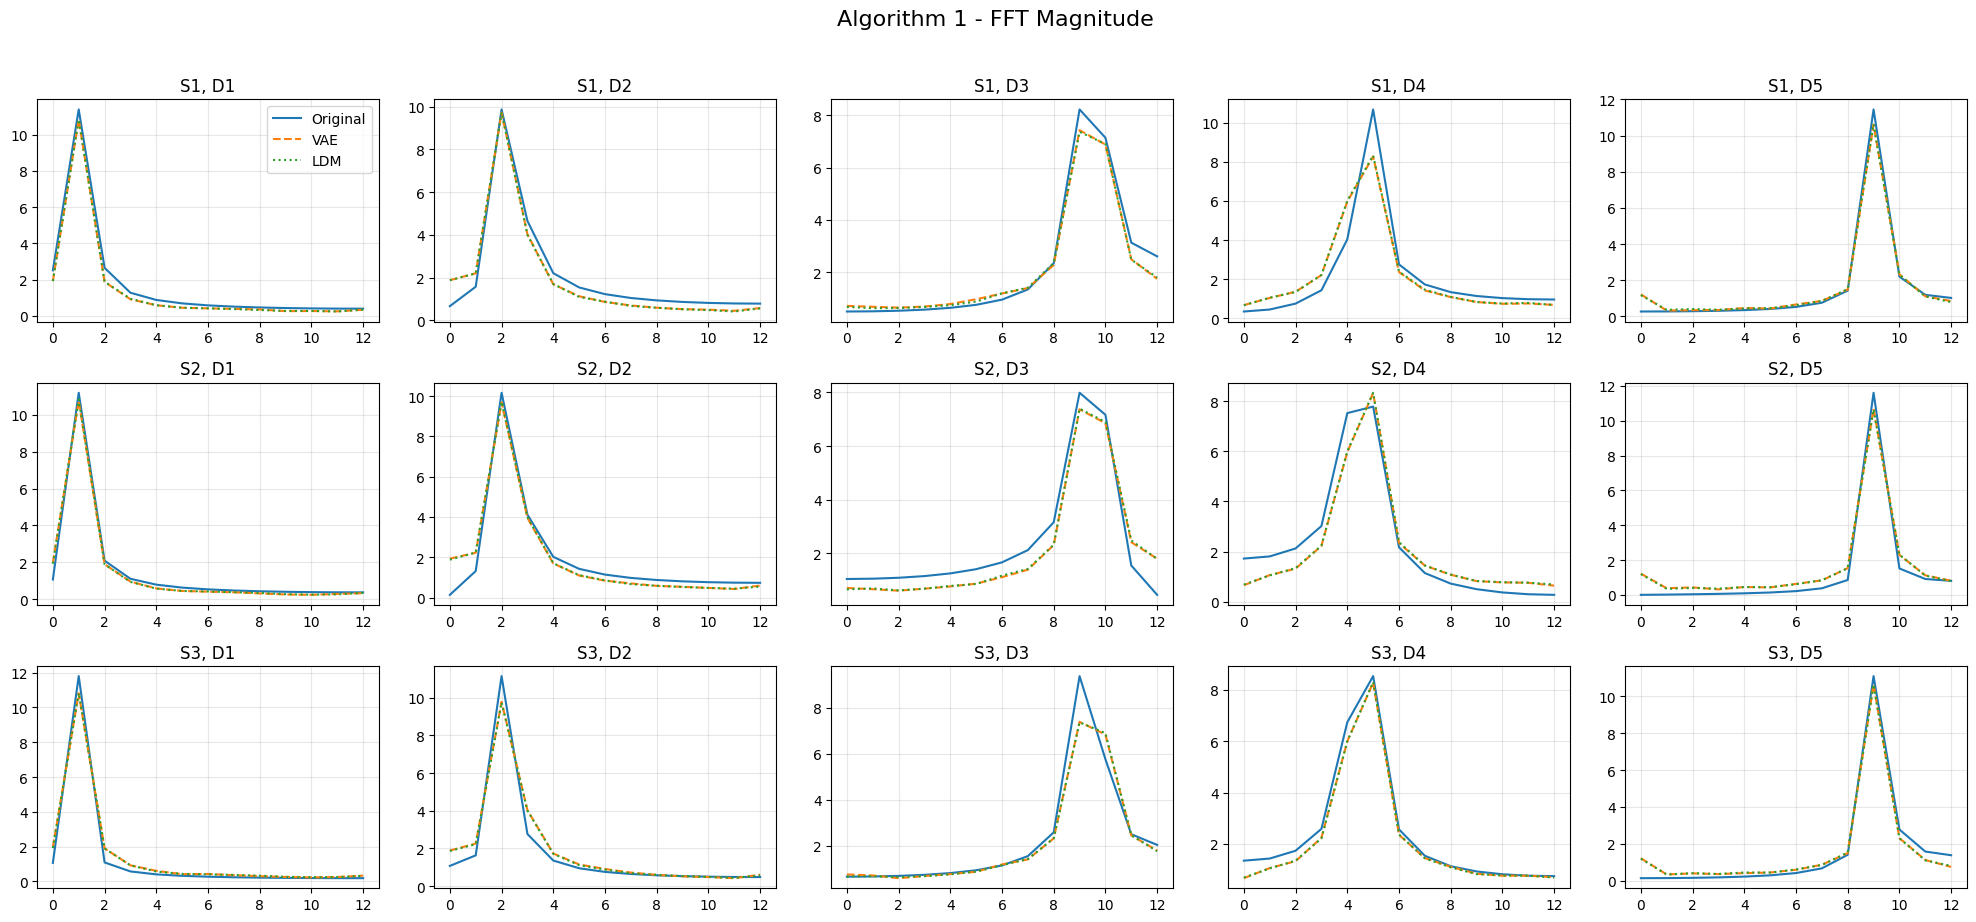

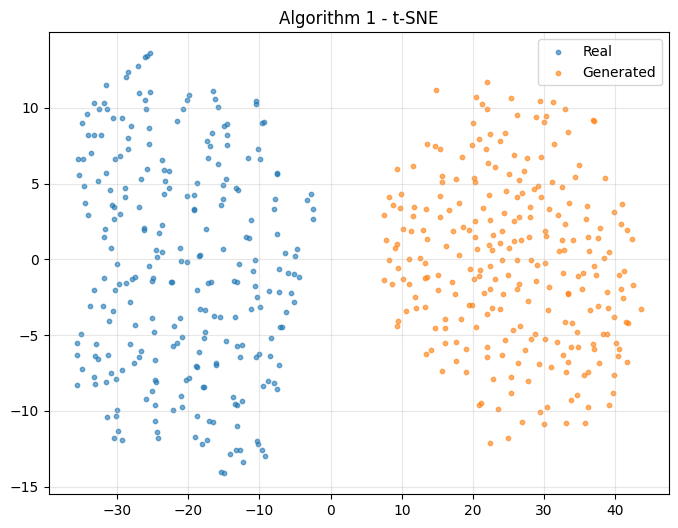

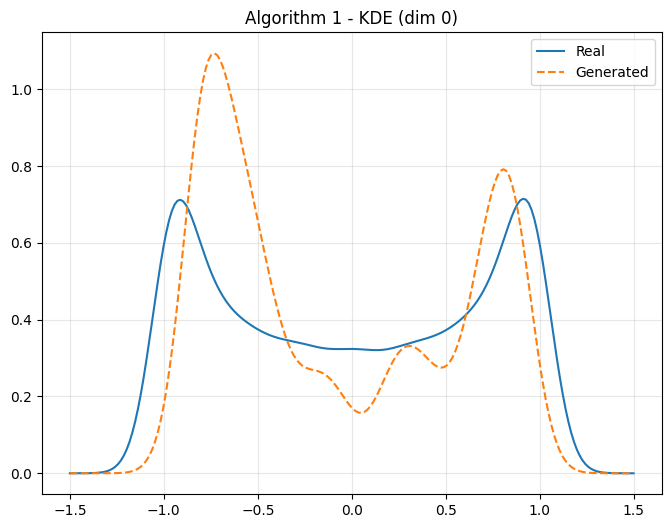

In [30]:
with torch.no_grad():
    vae_model.eval()
    real_batch = DATA[:100].to(device)
    mu, log_var = vae_model.encode(real_batch)
    z = vae_model.reparameterize(mu, log_var)
    vae_recon = vae_model.decode(z).cpu()

real_batch = real_batch.cpu()
samples_alg1 = samples_alg1.cpu()

plot_detailed_comparison(real_batch, vae_recon, samples_alg1[:100], "Algorithm 1", num_samples=3)
plot_frequency_analysis(real_batch, vae_recon, samples_alg1[:100], "Algorithm 1", num_samples=3)
plot_tsne_comparison(DATA[:500], samples_alg1[:500], "Algorithm 1")
plot_kde_comparison(DATA[:500], samples_alg1[:500], "Algorithm 1")

How about the metrics ?

In [31]:
metrics = evaluate_all_metrics(
    real=DATA[:1000],
    synth=samples_alg1[:1000],
    input_dim=5,
    seq_len=24,
    algorithm_name="Algorithm 1",
)

print(metrics)


Algorithm 1 - Evaluation Metrics
Context-FID Score: 2.4611
Correlational Score: 0.0515
Discriminative Score: 0.0000
Predictive Score: 0.6936
{'fid': np.float32(2.461083), 'correlational': 0.05150752142071724, 'discriminative': 0.0, 'predictive': 0.693561851978302}


## <ins style = "color : orange"> The second improved implementation. </ins>

### 1. Architectural changes

- **Increased latent dimension**:
$$
d_z: 16 \rightarrow 32
$$

- **Larger diffusion network**:
$$
\text{hidden dimension} = 512
$$

- **Time conditioning**:
Instead of additive conditioning, timestep embeddings are concatenated:
$$
h = [\text{Proj}(z_t), \; s_t]
$$

### 2. Regularization techniques

- **Spectral normalization** to control the Lipschitz constant and stabilize training  
- **Batch normalization** and **layer normalization** to improve gradient flow  
- **Dropout** to reduce overfitting  
- **Residual connections** to ease optimization  

### 3. Optimization improvements

- **AdamW optimizer** instead of Adam  
- **Xavier initialization** for better weight scaling  

### 4. KL regularization strategy

A KL warmup schedule is introduced:

$$
\beta(t) \uparrow \quad \text{from } 0 \text{ to } 1
$$

over the first training epochs, allowing the model to first focus on reconstruction before enforcing latent regularization.

### 5. Effect of improvements

These modifications lead to:

- increased diversity of generated samples  
- improved stability during training  
- better latent space structure  

However, they also introduce:

- higher noise in generated signals  
- reduced temporal coherence compared to the best configuration of Implementation 1  

This highlights a trade-off between diversity and signal fidelity.

In [32]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000):
        super().__init__()
        self.pe = nn.Parameter(torch.randn(1, max_len, d_model))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pe[:, :x.size(1), :]

In [33]:
class Algorithm3_VAEEncoder(nn.Module):
    def __init__(
        self,
        input_dim: int,
        latent_dim: int,
        num_heads: int = 2,
        num_layers: int = 2,
        seq_len: int = 24,
    ):
        super().__init__()
        self.seq_len = seq_len
        self.latent_dim = latent_dim

        self.embedding_cnn = nn.Sequential(
            spectral_norm(nn.Conv1d(input_dim, latent_dim, kernel_size=3, padding=1)),
            nn.BatchNorm1d(latent_dim),
            nn.ReLU(),
            spectral_norm(nn.Conv1d(latent_dim, latent_dim, kernel_size=3, padding=1)),
            nn.BatchNorm1d(latent_dim),
            nn.ReLU(),
        )

        self.pos_encoding = PositionalEncoding(latent_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=latent_dim,
            nhead=num_heads,
            dim_feedforward=latent_dim * 4,
            dropout=0.1,
            batch_first=True,
            activation="gelu",
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.norm = nn.LayerNorm(latent_dim)
        self.mean_head = spectral_norm(nn.Linear(latent_dim, latent_dim))
        self.logvar_head = spectral_norm(nn.Linear(latent_dim, latent_dim))

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        x = x.permute(0, 2, 1)
        x = self.embedding_cnn(x)
        x = x.permute(0, 2, 1)

        x = self.norm(x)
        x = self.pos_encoding(x)
        x = self.transformer(x)

        mean = self.mean_head(x)
        log_var = self.logvar_head(x)
        log_var = torch.clamp(log_var, min=-10.0, max=10.0)

        return mean, log_var

In [34]:
class Algorithm3_VAEDecoder(nn.Module):
    def __init__(
        self,
        latent_dim: int,
        output_dim: int,
        num_heads: int = 2,
        num_layers: int = 3,
        seq_len: int = 24,
    ):
        super().__init__()

        self.embedding = spectral_norm(nn.Linear(latent_dim, latent_dim))
        self.norm = nn.LayerNorm(latent_dim)
        self.pos_encoding = PositionalEncoding(latent_dim)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=latent_dim,
            nhead=num_heads,
            dim_feedforward=latent_dim * 4,
            dropout=0.1,
            batch_first=True,
            activation="gelu",
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)

        self.output_proj = nn.Sequential(
            spectral_norm(nn.Linear(latent_dim, latent_dim * 2)),
            nn.GELU(),
            nn.Dropout(0.1),
            spectral_norm(nn.Linear(latent_dim * 2, latent_dim)),
            nn.GELU(),
            spectral_norm(nn.Linear(latent_dim, output_dim)),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        z = self.embedding(z)
        z = self.norm(z)
        z = self.pos_encoding(z)

        decoded = self.decoder(z, z)
        reconstructed = self.output_proj(decoded)

        return reconstructed

In [35]:
class Algorithm3_TimeVAE(nn.Module):
    def __init__(
        self,
        input_dim: int,
        latent_dim: int,
        num_heads: int = 2,
        encoder_layers: int = 2,
        decoder_layers: int = 3,
        seq_len: int = 24,
        beta_max: float = 5e-3,
        beta_min: float = 1e-6,
        lambda_beta: float = 0.7,
        kl_warmup_epochs: int = 10,
    ):
        super().__init__()

        self.encoder = Algorithm3_VAEEncoder(
            input_dim=input_dim,
            latent_dim=latent_dim,
            num_heads=num_heads,
            num_layers=encoder_layers,
            seq_len=seq_len,
        )
        self.decoder = Algorithm3_VAEDecoder(
            latent_dim=latent_dim,
            output_dim=input_dim,
            num_heads=num_heads,
            num_layers=decoder_layers,
            seq_len=seq_len,
        )

        self.beta = beta_max
        self.beta_max = beta_max
        self.beta_min = beta_min
        self.lambda_beta = lambda_beta

        self.recon_stagnation_steps = 0
        self.best_recon_loss = float("inf")

        self.kl_warmup_epochs = kl_warmup_epochs
        self.current_epoch = 0

    def reparameterize(self, mean: torch.Tensor, log_var: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mean + eps * std

    def fft_loss_fixed(self, x: torch.Tensor, x_hat: torch.Tensor) -> torch.Tensor:
        x_fft = torch.fft.rfft(x, dim=1)
        x_hat_fft = torch.fft.rfft(x_hat, dim=1)
        return F.mse_loss(torch.abs(x_fft), torch.abs(x_hat_fft))
    
    def forward(
        self,
        x: torch.Tensor,
        lambda1: float = 1.0,
        lambda2: float = 1.0,
        lambda3: float = 1.0,
        epoch: int | None = None,
    ):
        if epoch is not None:
            self.current_epoch = epoch

        mean, log_var = self.encoder(x)
        z = self.reparameterize(mean, log_var)
        x_hat = self.decoder(z)

        l2_loss = F.mse_loss(x_hat, x)
        l1_loss = F.l1_loss(x_hat, x)
        fft_loss_val = self.fft_loss_fixed(x, x_hat)

        recon_loss = lambda1 * l2_loss + lambda2 * l1_loss + lambda3 * fft_loss_val
        kl_loss = -0.5 * torch.mean(1 + log_var - mean.pow(2) - log_var.exp())

        if self.current_epoch < self.kl_warmup_epochs:
            kl_weight = self.current_epoch / self.kl_warmup_epochs
        else:
            kl_weight = 1.0

        return x_hat, recon_loss, kl_loss * kl_weight, z
    
    def update_beta(self, current_recon_loss: float) -> bool:
        if current_recon_loss < self.best_recon_loss * 0.99:
            self.best_recon_loss = current_recon_loss
            self.recon_stagnation_steps = 0
        else:
            self.recon_stagnation_steps += 1

        if self.recon_stagnation_steps > 3:
            self.beta = max(self.beta * self.lambda_beta, self.beta_min)
            self.recon_stagnation_steps = 0
            return True

        return False

In [36]:
class Algorithm3_ImprovedLatentDiffusionMLP(nn.Module):
    def __init__(
        self,
        latent_dim: int,
        hidden_dim: int = 512,
        seq_len: int = 24,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.latent_dim = latent_dim
        self.total_dim = seq_len * latent_dim

        self.time_embed = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.input_proj = nn.Sequential(
            nn.Linear(self.total_dim + hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
        )

        self.blocks = nn.ModuleList()
        for _ in range(4):
            block = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.LayerNorm(hidden_dim),
                nn.SiLU(),
                nn.Dropout(0.1),
                nn.Linear(hidden_dim, hidden_dim),
                nn.LayerNorm(hidden_dim),
            )

            for m in block.modules():
                if isinstance(m, nn.Linear):
                    nn.init.xavier_uniform_(m.weight, gain=0.1)
                    if m.bias is not None:
                        nn.init.zeros_(m.bias)

            self.blocks.append(block)

        self.skip_proj = nn.Linear(hidden_dim, hidden_dim)
        nn.init.xavier_uniform_(self.skip_proj.weight, gain=0.1)

        self.output_proj = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, self.total_dim),
        )
        nn.init.xavier_uniform_(self.output_proj[0].weight, gain=0.1)
        nn.init.xavier_uniform_(self.output_proj[3].weight, gain=0.01)
        nn.init.zeros_(self.output_proj[3].bias)
    
    def forward(self, z_t: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        batch_size = z_t.size(0)

        z_flat = z_t.reshape(batch_size, -1)
        t_emb = self.time_embed(t.float().view(-1, 1))

        h = torch.cat([z_flat, t_emb], dim=1)
        h = self.input_proj(h)

        for block in self.blocks:
            h_res = h
            h = block(h)
            h = h + self.skip_proj(h_res)

        out = self.output_proj(h)
        return out.reshape(batch_size, self.seq_len, self.latent_dim)

In [37]:
class ScoreBasedDiffusion:
    def __init__(self, T: int = 500, sigma_min: float = 0.01, sigma_max: float = 10.0):
        self.T = T
        self.sigma_min = sigma_min
        self.sigma_max = sigma_max

    def noise_level(self, t: torch.Tensor) -> torch.Tensor:
        return t

    def forward_process(self, z_0: torch.Tensor, t: torch.Tensor):
        t = t.view(-1, 1, 1)
        sigma_t = self.noise_level(t)

        noise = torch.randn_like(z_0)
        z_t = z_0 + sigma_t * noise

        return z_t, noise

In [38]:
class Algorithm3_TimeLDM(nn.Module):
    def __init__(
        self,
        input_dim: int,
        latent_dim: int = 32,
        seq_len: int = 24,
        num_heads: int = 2,
        encoder_layers: int = 2,
        decoder_layers: int = 3,
        ldm_hidden_dim: int = 512,
        beta_max: float = 5e-3,
        beta_min: float = 1e-6,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.latent_dim = latent_dim
        self.input_dim = input_dim

        self.vae = Algorithm3_TimeVAE(
            input_dim=input_dim,
            latent_dim=latent_dim,
            num_heads=num_heads,
            encoder_layers=encoder_layers,
            decoder_layers=decoder_layers,
            seq_len=seq_len,
            beta_max=beta_max,
            beta_min=beta_min,
            kl_warmup_epochs=10,
        )

        self.ldm = Algorithm3_ImprovedLatentDiffusionMLP(
            latent_dim=latent_dim,
            hidden_dim=ldm_hidden_dim,
            seq_len=seq_len,
        )

        self.diffusion = ScoreBasedDiffusion(T=500)

    def encode(self, x: torch.Tensor):
        mean, log_var = self.vae.encoder(x)
        z = self.vae.reparameterize(mean, log_var)
        return z, mean, log_var

    def decode(self, z: torch.Tensor):
        return self.vae.decoder(z)

    def forward_vae(self, x, lambda1=1.0, lambda2=1.0, lambda3=1.0, epoch=None):
        return self.vae(x, lambda1, lambda2, lambda3, epoch)

    def forward_ldm(self, z_0: torch.Tensor):
        batch_size = z_0.size(0)
        t = torch.rand(batch_size, device=z_0.device) * self.diffusion.T
        z_t, noise = self.diffusion.forward_process(z_0, t)
        noise_pred = self.ldm(z_t, t)
        return noise_pred, noise

    def denoise(self, z_t: torch.Tensor, t: torch.Tensor):
        return self.ldm(z_t, t)

In [39]:
def train_algorithm3_vae(
    model,
    data,
    vae_epochs: int = 30,
    batch_size: int = 1024,
    device: str = "cuda",
):
    model = model.to(device)
    data = data.to(device)

    optimizer = optim.AdamW(model.vae.parameters(), lr=1e-3, weight_decay=1e-5)

    print("\nStep 1: Training Enhanced VAE...")
    for epoch in tqdm(range(vae_epochs), desc="Algorithm 3 - VAE"):
        model.train()
        perm = torch.randperm(len(data))
        epoch_recon_loss = 0.0
        n_batches = 0

        for i in range(0, len(data), batch_size):
            idx = perm[i:i + batch_size]
            x = data[idx]

            x_hat, recon_loss, kl_loss, _ = model.forward_vae(x, epoch=epoch)
            total_loss = recon_loss + model.vae.beta * kl_loss

            optimizer.zero_grad()
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.vae.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_recon_loss += recon_loss.item()
            n_batches += 1

        avg_recon_loss = epoch_recon_loss / n_batches
        model.vae.update_beta(avg_recon_loss)

    return model

In [40]:
@torch.no_grad()
def extract_algorithm3_latents(model, data, batch_size=1024, device="cuda"):
    model.eval()
    all_z = []

    for i in range(0, len(data), batch_size):
        x_batch = data[i:i + batch_size].to(device)
        z, _, _ = model.encode(x_batch)
        all_z.append(z.cpu())

    return torch.cat(all_z, dim=0)

In [41]:
def train_algorithm3_ldm(
    model,
    z0_all,
    ldm_epochs: int = 30,
    batch_size: int = 1024,
    device: str = "cuda",
):
    optimizer = optim.AdamW(model.ldm.parameters(), lr=2e-4, betas=(0.9, 0.96))

    print("\nStep 3: Training Enhanced LDM...")
    for epoch in tqdm(range(ldm_epochs), desc="Algorithm 3 - LDM"):
        model.train()
        perm = torch.randperm(len(z0_all))

        for i in range(0, len(z0_all), batch_size):
            idx = perm[i:i + batch_size]
            z0 = z0_all[idx].to(device)

            noise_pred, noise = model.forward_ldm(z0)
            loss = F.mse_loss(noise_pred, noise)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.ldm.parameters(), max_norm=1.0)
            optimizer.step()

    return model

In [42]:
def train_algorithm3(
    model,
    data,
    vae_epochs=30,
    ldm_epochs=30,
    batch_size=1024,
    device="cuda",
):
    model = train_algorithm3_vae(
        model=model,
        data=data,
        vae_epochs=vae_epochs,
        batch_size=batch_size,
        device=device,
    )

    print("\nStep 2: Extracting latents for LDM...")
    z0_all = extract_algorithm3_latents(
        model=model,
        data=data,
        batch_size=batch_size,
        device=device,
    )

    model = train_algorithm3_ldm(
        model=model,
        z0_all=z0_all,
        ldm_epochs=ldm_epochs,
        batch_size=batch_size,
        device=device,
    )

    return model

In [43]:
@torch.no_grad()
def sample_algorithm3(
    model,
    num_samples,
    seq_len,
    latent_dim,
    device,
    num_steps=500,
):
    model.eval()

    z_t = torch.randn(num_samples, seq_len, latent_dim, device=device)
    T_val = model.diffusion.T
    dt = T_val / num_steps

    for i in range(num_steps, 0, -1):
        t = torch.ones(num_samples, device=device) * i * dt
        noise_pred = model.denoise(z_t, t)
        sigma_t = model.diffusion.noise_level(t).view(-1, 1, 1)

        z_t = z_t - 2 * sigma_t * noise_pred * dt + \
              torch.sqrt(2 * sigma_t * dt) * torch.randn_like(z_t)

    return model.decode(z_t)

In [44]:
seq_len = 24
input_dim = 5
latent_dim = 32

data_algo3 = DATA.to(device)

model_algo3 = Algorithm3_TimeLDM(
    input_dim=input_dim,
    latent_dim=latent_dim,
    seq_len=seq_len,
    num_heads=2,
    encoder_layers=2,
    decoder_layers=3,
    ldm_hidden_dim=512,
)

In [45]:
model_algo3 = train_algorithm3(
    model=model_algo3,
    data=data_algo3,
    vae_epochs=30,
    ldm_epochs=30,
    batch_size=1024,
    device=device,
)


Step 1: Training Enhanced VAE...


Algorithm 3 - VAE: 100%|██████████| 30/30 [00:13<00:00,  2.23it/s]



Step 2: Extracting latents for LDM...

Step 3: Training Enhanced LDM...


Algorithm 3 - LDM: 100%|██████████| 30/30 [00:03<00:00,  8.25it/s]


In [46]:
with torch.no_grad():
    model_algo3.eval()
    test_data_algo3 = data_algo3[:100]
    z_test, _, _ = model_algo3.encode(test_data_algo3)
    vae_recon_algo3 = model_algo3.decode(z_test)

In [47]:
print("\nStep 4: Generating samples...")
synth_algo3 = sample_algorithm3(
    model=model_algo3,
    num_samples=1000,
    seq_len=seq_len,
    latent_dim=latent_dim,
    device=device,
    num_steps=500,
)


Step 4: Generating samples...


In [48]:
test_data_cpu_algo3 = test_data_algo3.cpu()
vae_recon_cpu_algo3 = vae_recon_algo3.cpu()
synth_algo3_cpu = synth_algo3.cpu()
data_cpu_algo3 = data_algo3.cpu()

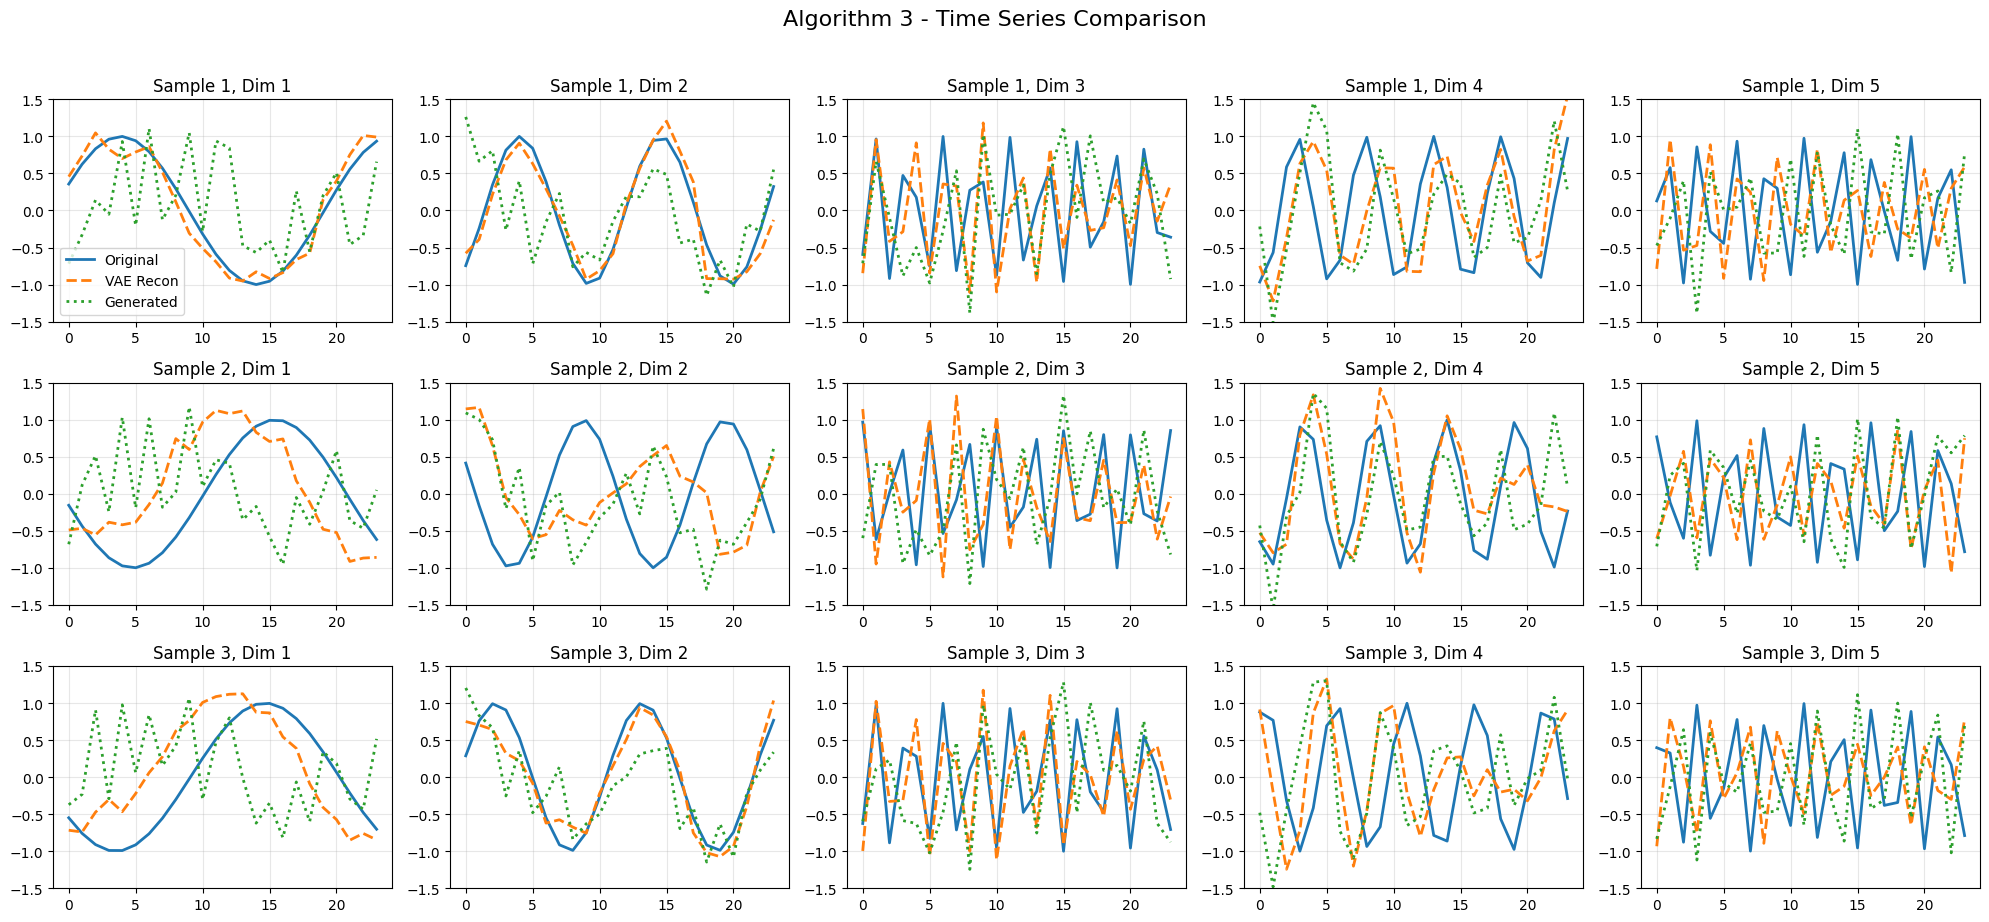

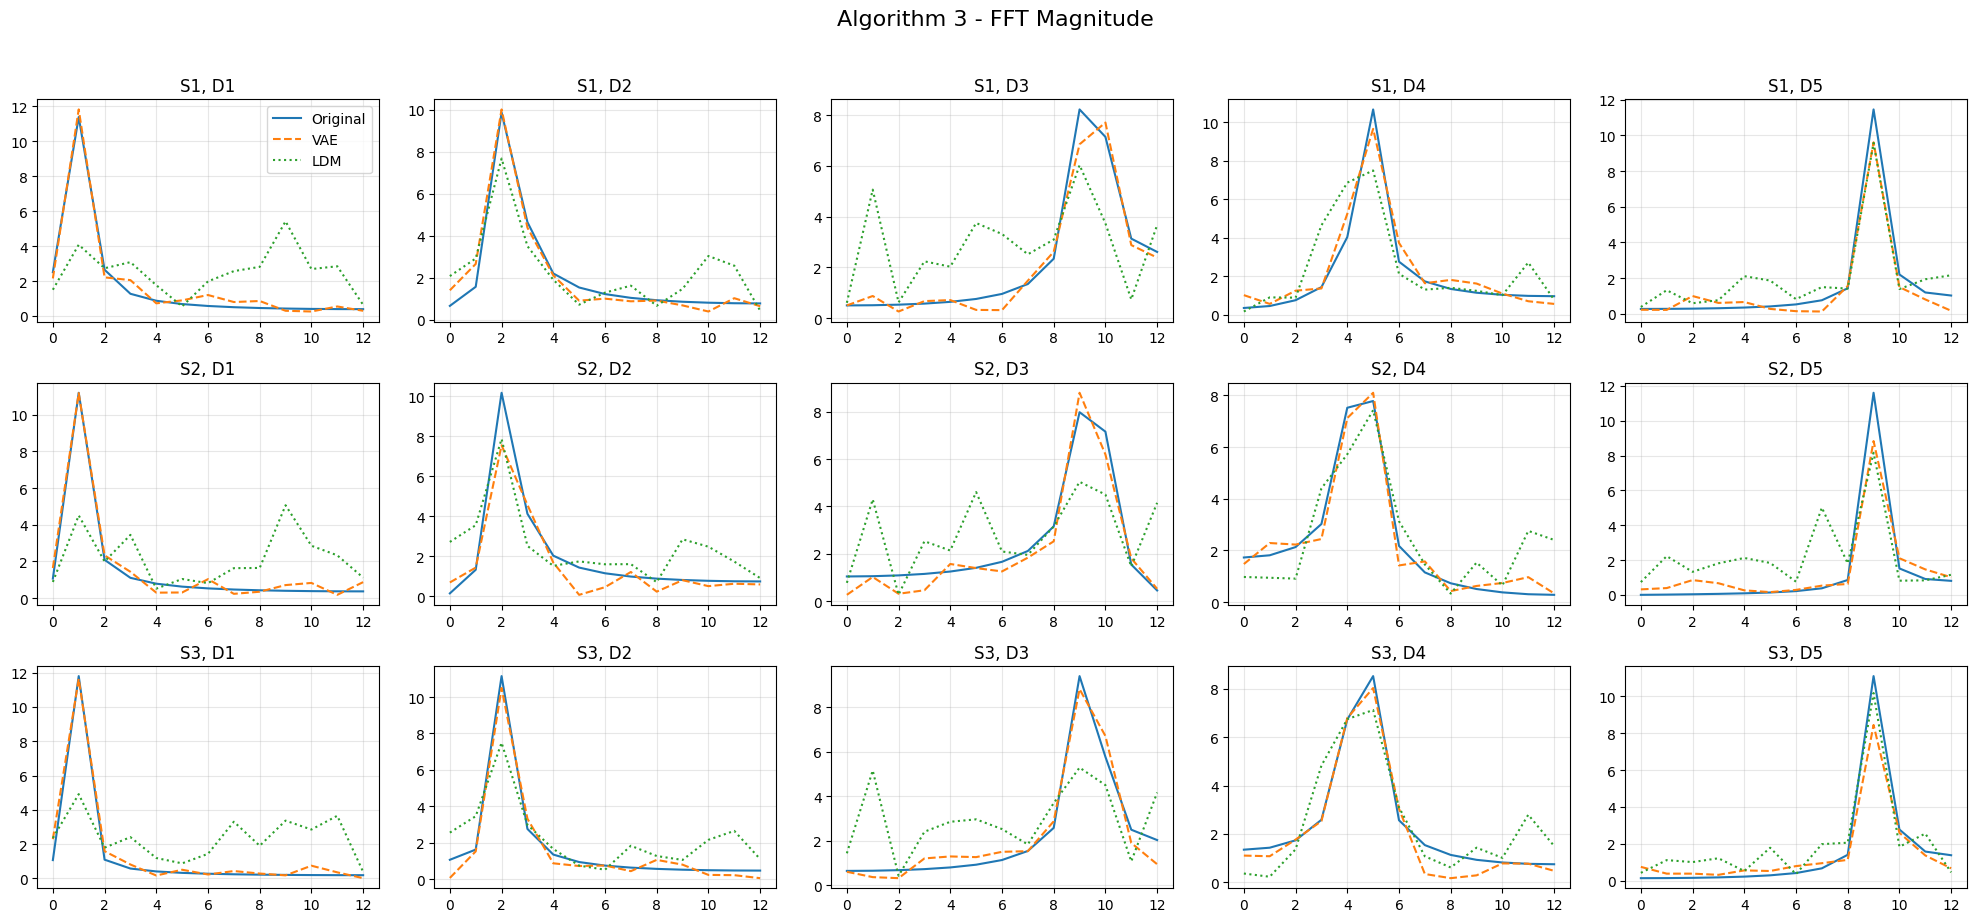

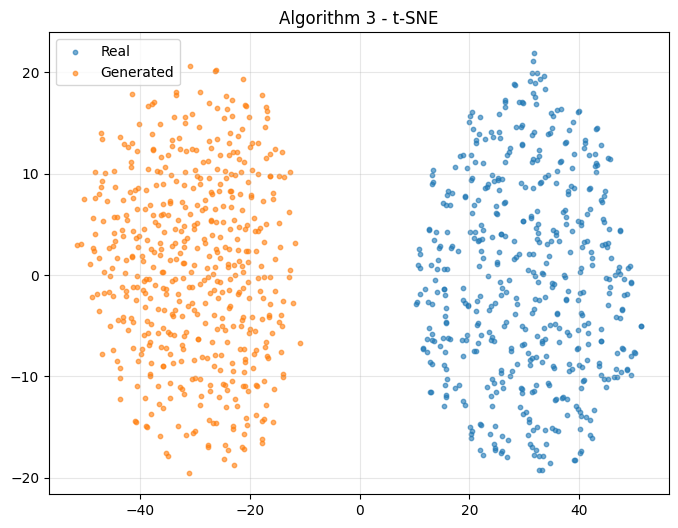

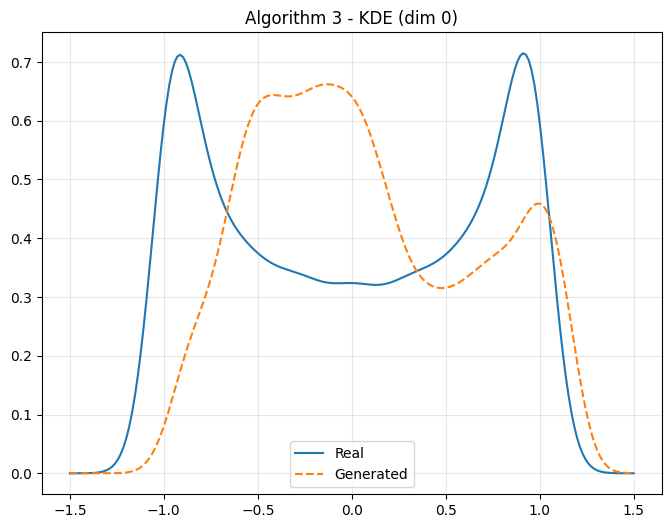

In [49]:
plot_detailed_comparison(
    test_data_cpu_algo3,
    vae_recon_cpu_algo3,
    synth_algo3_cpu[:100],
    algorithm_name="Algorithm 3",
    num_samples=3,
)

plot_frequency_analysis(
    test_data_cpu_algo3,
    vae_recon_cpu_algo3,
    synth_algo3_cpu[:100],
    algorithm_name="Algorithm 3",
    num_samples=3,
)

plot_tsne_comparison(
    data_cpu_algo3[:500],
    synth_algo3_cpu[:500],
    algorithm_name="Algorithm 3",
)

plot_kde_comparison(
    data_cpu_algo3[:500],
    synth_algo3_cpu[:500],
    algorithm_name="Algorithm 3",
)

In [ ]:
metrics_algo3 = evaluate_all_metrics(
    data_cpu_algo3,
    synth_algo3_cpu,
    seq_len,
    input_dim,
    "Algorithm 3",
)


Algorithm 3 - Evaluation Metrics
Context-FID Score: 10.0575
Correlational Score: 0.0733
Discriminative Score: 0.0000
Predictive Score: 0.5760


## <ins style = "color : orange"> Explainability. </ins>


We first define the latent diffusion sampling algorithm and setting gradient as True for the next steps. 

In [51]:
def sample_algorithm1_ldm_differentiable(
    ldm_model,
    vae_model,
    z_init,
    T: float = 1.0,
    steps: int = 100,
):
    """
    Deterministic reverse process for explainability.
    z_init: (B, seq_len, latent_dim)
    returns generated samples: (B, seq_len, input_dim)
    """
    ldm_model.eval()
    vae_model.eval()

    z_t = z_init
    dt = T / steps

    for i in range(steps, 0, -1):
        t_val = i * dt
        t = torch.full((z_t.size(0),), t_val, device=z_t.device)

        eps_pred = ldm_model(z_t, t)
        score = -eps_pred / (t_val + 1e-5)

        z_t = z_t + 2.0 * t_val * score * dt

    x_gen = vae_model.decode(z_t)
    return x_gen

We define the target features of the sine waves as scalar quantities capturing their statistical and spectral properties. In particular, we consider the mean, the dominant frequency, and the signal energy of a selected output dimension.

### Mean

$$
\mu = \frac{1}{T} \sum_{t=1}^{T} x_t
$$

### Signal energy

$$
E = \sum_{t=1}^{T} x_t^2
$$

### Dominant frequency

Let $\hat{x} = FFT(x)$. The dominant frequency is defined as the index of the maximum magnitude:

$$
f_{\text{max}} = \arg\max_k |\hat{x}_k|
$$

In [52]:
def target_value_at_time_dim(x, time_idx: int, dim_idx: int):
    """
    x: (B, seq_len, input_dim)
    returns: (B,)
    """
    return x[:, time_idx, dim_idx]


def target_mean_on_dim(x, dim_idx: int):
    """
    Mean value over time for one dimension.
    """
    return x[:, :, dim_idx].mean(dim=1)


def target_energy_on_dim(x, dim_idx: int):
    """
    Mean squared amplitude over time for one dimension.
    """
    return (x[:, :, dim_idx] ** 2).mean(dim=1)


def target_fft_peak_on_dim(x, dim_idx: int):
    """
    Mean of top-3 FFT magnitudes for one dimension.
    """
    fft_mag = torch.fft.rfft(x[:, :, dim_idx], dim=1).abs()
    return fft_mag.topk(k=min(3, fft_mag.shape[1]), dim=1).values.mean(dim=1)

### Does Saliency analysis make sense ?

We highlight below why using Siliency maps does not make much sense in the case of latent diffusion models plugged with VAEs. Since we are feeding noise to the model, we can not interpret effectively the channel activations.    

In [53]:
def compute_saliency_algorithm1(
    ldm_model,
    vae_model,
    z_init,
    target_fn,
    T: float = 1.0,
    steps: int = 100,
):
    """
    z_init: (1, seq_len, latent_dim) or (B, seq_len, latent_dim)
    target_fn: function mapping generated x -> scalar per sample

    returns:
        x_gen: generated sample
        saliency: abs grad wrt z_init, same shape as z_init
        target_value: scalar tensor
    """
    z = z_init.clone().detach().requires_grad_(True)

    x_gen = sample_algorithm1_ldm_differentiable(
        ldm_model=ldm_model,
        vae_model=vae_model,
        z_init=z,
        T=T,
        steps=steps,
    )

    target = target_fn(x_gen).sum()
    target.backward()

    saliency = z.grad.abs().detach()
    return x_gen.detach(), saliency, target.detach()

In [54]:
def plot_latent_saliency_heatmap(saliency, title="Latent Saliency"):
    """
    saliency: (1, seq_len, latent_dim) or (seq_len, latent_dim)
    """
    if saliency.dim() == 3:
        saliency = saliency[0]

    saliency_np = saliency.detach().cpu().numpy()

    plt.figure(figsize=(8, 5))
    plt.imshow(saliency_np, aspect="auto", origin="lower")
    plt.colorbar(label="|gradient|")
    plt.xlabel("Latent dimension")
    plt.ylabel("Time index")
    plt.title(title)
    plt.show()

In [55]:
def plot_generated_series_with_temporal_saliency(x_gen, saliency, dim_idx=0, title="Temporal Saliency"):
    """
    x_gen: (1, seq_len, input_dim)
    saliency: (1, seq_len, latent_dim)
    """
    x = x_gen[0, :, dim_idx].detach().cpu().numpy()
    s = saliency[0].mean(dim=1).detach().cpu().numpy()

    s = (s - s.min()) / (s.max() - s.min() + 1e-8)

    plt.figure(figsize=(10, 4))
    plt.plot(x, linewidth=2, label=f"Generated dim {dim_idx}")
    plt.scatter(np.arange(len(x)), x, c=s, s=80)
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

Target value: 5.319860458374023


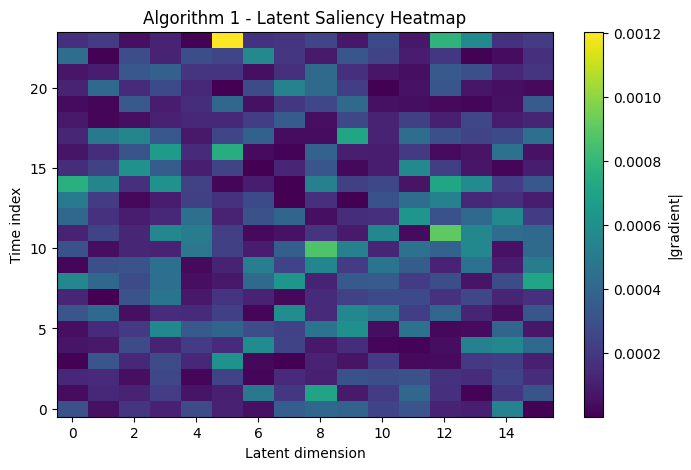

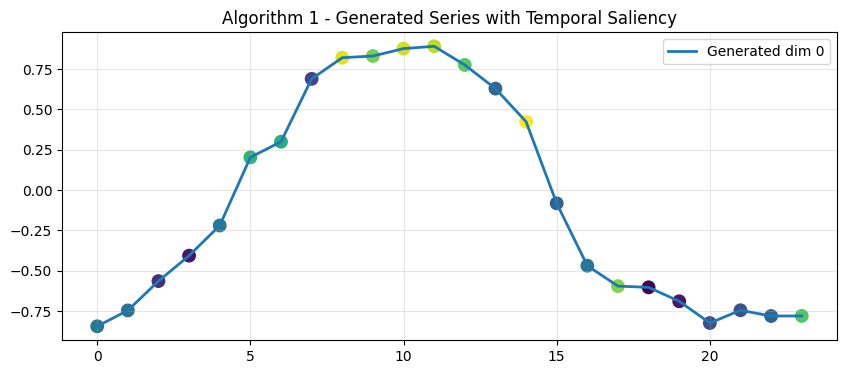

In [56]:
seq_len = 24
latent_dim = 16

z0 = torch.randn(1, seq_len, latent_dim, device=device)

target_fn = lambda x: target_fft_peak_on_dim(x, dim_idx=1)

x_gen, saliency, target_val = compute_saliency_algorithm1(
    ldm_model=ldm_model,
    vae_model=vae_model,
    z_init=z0,
    target_fn=target_fn,
    T=1.0,
    steps=100,
)

print("Target value:", target_val.item())

plot_latent_saliency_heatmap(
    saliency,
    title="Algorithm 1 - Latent Saliency Heatmap",
)

plot_generated_series_with_temporal_saliency(
    x_gen,
    saliency,
    dim_idx=0,
    title="Algorithm 1 - Generated Series with Temporal Saliency",
)

### Counterfactual explanation

We analyze the generative model by optimizing the latent representation to enforce structured transformations in the generated time series. Given an initial latent variable $z_0$, we seek a modified latent $z_{cf}$ such that the generated output satisfies a desired condition while remaining close to the original latent:

$$
z_{cf} = \arg\min_{z} \; \mathcal{L}_{\text{swap}}(f(z)) + \lambda_{\text{prox}} \|z - z_0\|_2^2
$$

where $f(z)$ denotes the full generative process (diffusion + decoding).

In particular, we consider channel-swapping counterfactuals. For two output channels $i$ and $j$, the loss is defined as:

$$
\mathcal{L}_{\text{swap}} =
\|x^{(i)}_{cf} - x^{(j)}_{\text{orig}}\|_2^2 +
\|x^{(j)}_{cf} - x^{(i)}_{\text{orig}}\|_2^2
$$

where $x_{cf} = f(z_{cf})$ and $x_{\text{orig}} = f(z_0)$.

This formulation allows us to test whether channel-specific patterns can be reassigned through latent perturbations. Ideally, in a disentangled representation, such a transformation would only affect the targeted channels while leaving the others unchanged.

In practice, we observe that channel swapping can be partially achieved while preserving other channels. This indicates that the latent space is only weakly disentangled and that information is distributed across multiple latent dimensions.

In [57]:
def generate_counterfactual_algorithm1(
    ldm_model,
    vae_model,
    z_init,
    target_fn,
    target_value,
    T: float = 1.0,
    steps: int = 100,
    cf_steps: int = 300,
    lr: float = 5e-2,
    lambda_prox: float = 1e-2,
):
    """
    target_value: desired scalar value
    lambda_prox: keeps counterfactual close to original latent
    """
    z_orig = z_init.clone().detach()
    z_cf = z_init.clone().detach().requires_grad_(True)

    optimizer = torch.optim.Adam([z_cf], lr=lr)

    history = []

    for _ in range(cf_steps):
        x_cf = sample_algorithm1_ldm_differentiable(
            ldm_model=ldm_model,
            vae_model=vae_model,
            z_init=z_cf,
            T=T,
            steps=steps,
        )

        y_cf = target_fn(x_cf)
        loss_target = ((y_cf - target_value) ** 2).mean()
        loss_prox = ((z_cf - z_orig) ** 2).mean()
        loss = loss_target + lambda_prox * loss_prox

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        history.append(loss.item())

    with torch.no_grad():
        x_orig = sample_algorithm1_ldm_differentiable(
            ldm_model=ldm_model,
            vae_model=vae_model,
            z_init=z_orig,
            T=T,
            steps=steps,
        )
        x_cf = sample_algorithm1_ldm_differentiable(
            ldm_model=ldm_model,
            vae_model=vae_model,
            z_init=z_cf,
            T=T,
            steps=steps,
        )

    return x_orig, x_cf, z_orig, z_cf.detach(), history

In [58]:
def generate_swap_counterfactual_algorithm1(
    ldm_model,
    vae_model,
    z_init,
    ch1: int = 0,
    ch2: int = 1,
    T: float = 1.0,
    steps: int = 100,
    cf_steps: int = 1000,
    lr: float = 1e-2,
    lambda_prox: float = 1e-2,
    lambda_keep_others: float = 1.0,
):
    """
    Optimize the latent code so that output channels ch1 and ch2 are swapped,
    while keeping the counterfactual latent close to the original one.
    """

    z_orig = z_init.clone().detach()
    z_cf = z_init.clone().detach().requires_grad_(True)

    # Original output used as reference
    with torch.no_grad():
        x_orig = sample_algorithm1_ldm_differentiable(
            ldm_model=ldm_model,
            vae_model=vae_model,
            z_init=z_orig,
            T=T,
            steps=steps,
        )

        x_target = x_orig.clone()
        x_target[..., ch1] = x_orig[..., ch2]
        x_target[..., ch2] = x_orig[..., ch1]

    optimizer = torch.optim.Adam([z_cf], lr=lr)
    history = []

    for _ in range(cf_steps):
        x_cf = sample_algorithm1_ldm_differentiable(
            ldm_model=ldm_model,
            vae_model=vae_model,
            z_init=z_cf,
            T=T,
            steps=steps,
        )

        # Force swapped channels
        loss_swap = (
            ((x_cf[..., ch1] - x_target[..., ch1]) ** 2).mean()
            + ((x_cf[..., ch2] - x_target[..., ch2]) ** 2).mean()
        )

        # Keep the other channels similar to the original output
        other_idx = [i for i in range(x_cf.shape[-1]) if i not in [ch1, ch2]]
        if len(other_idx) > 0:
            loss_keep = ((x_cf[..., other_idx] - x_orig[..., other_idx]) ** 2).mean()
        else:
            loss_keep = 0.0

        # Keep latent close to original
        loss_prox = ((z_cf - z_orig) ** 2).mean()

        loss = loss_swap + lambda_keep_others * loss_keep + lambda_prox * loss_prox

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        history.append(loss.item())

    with torch.no_grad():
        x_cf_final = sample_algorithm1_ldm_differentiable(
            ldm_model=ldm_model,
            vae_model=vae_model,
            z_init=z_cf,
            T=T,
            steps=steps,
        )

    return x_orig, x_target, x_cf_final, z_orig, z_cf.detach(), history

In [59]:
def plot_counterfactual_comparison(x_orig, x_cf, dim_idx=0, title="Counterfactual Comparison"):
    orig = x_orig[0, :, dim_idx].detach().cpu().numpy()
    cf = x_cf[0, :, dim_idx].detach().cpu().numpy()

    plt.figure(figsize=(10, 4))
    plt.plot(orig, label="Original", linewidth=2)
    plt.plot(cf, "--", label="Counterfactual", linewidth=2)
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

In [ ]:
z0 = torch.randn(1, seq_len, latent_dim, device=device)

x_orig, x_target, x_cf, z_orig, z_cf, history = generate_swap_counterfactual_algorithm1(
    ldm_model=ldm_model,
    vae_model=vae_model,
    z_init=z0,
    ch1=0,
    ch2=1,
    T=1.0,
    steps=100,
    cf_steps=5000,
    lr=1e-2,
    lambda_prox=1e-2,
    lambda_keep_others=1.0,
)

plot_counterfactual_comparison(
    x_orig,
    x_cf,
    dim_idx=0,
    title="Algorithm 1 - Swap counterfactual on output channel 0",
)

plt.figure(figsize=(6, 3))
plt.plot(history)
plt.title("Counterfactual optimization loss")
plt.grid(alpha=0.3)
plt.show()

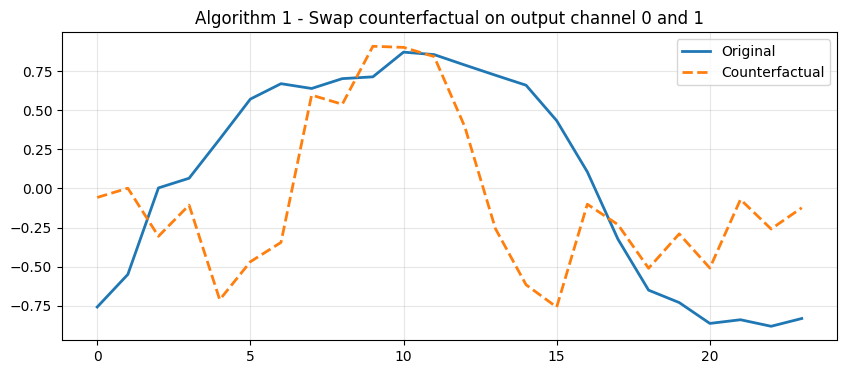

In [ ]:
plot_counterfactual_comparison(
    x_orig,
    x_cf,
    dim_idx=0,
    title="Algorithm 1 - Swap counterfactual on output channel 0 and 1",
)

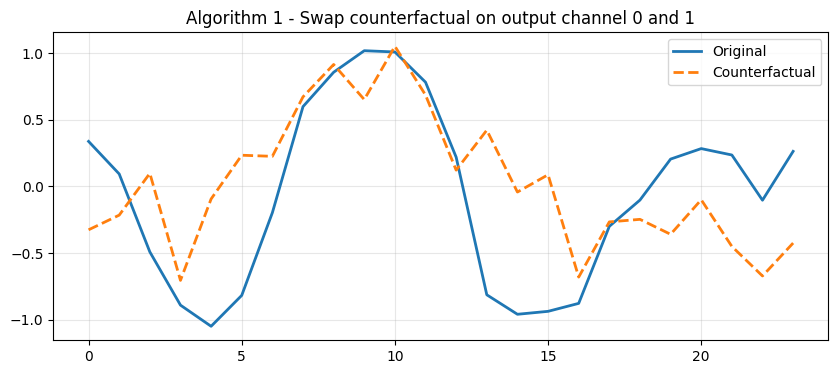

In [ ]:
plot_counterfactual_comparison(
    x_orig,
    x_cf,
    dim_idx=1,
    title="Algorithm 1 - Swap counterfactual on output channel 0 and 1",
)

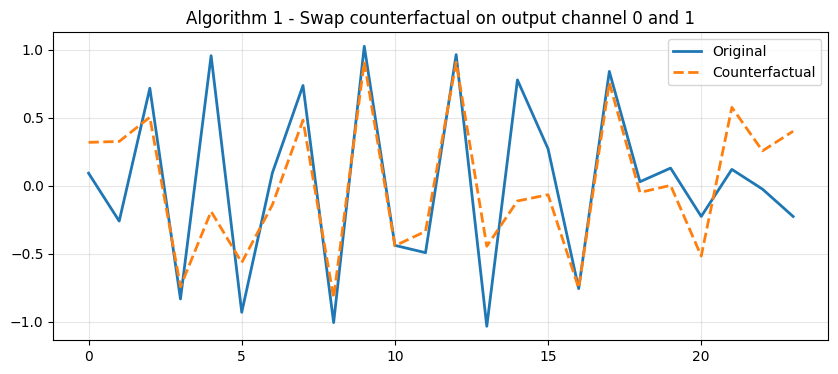

In [ ]:
plot_counterfactual_comparison(
    x_orig,
    x_cf,
    dim_idx=2,
    title="Algorithm 1 - Swap counterfactual on output channel 0 and 1",
)

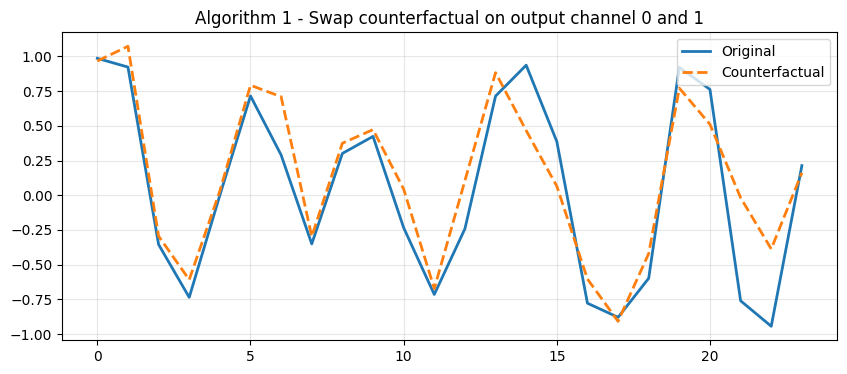

In [ ]:
plot_counterfactual_comparison(
    x_orig,
    x_cf,
    dim_idx=3,
    title="Algorithm 1 - Swap counterfactual on output channel 0 and 1",
)

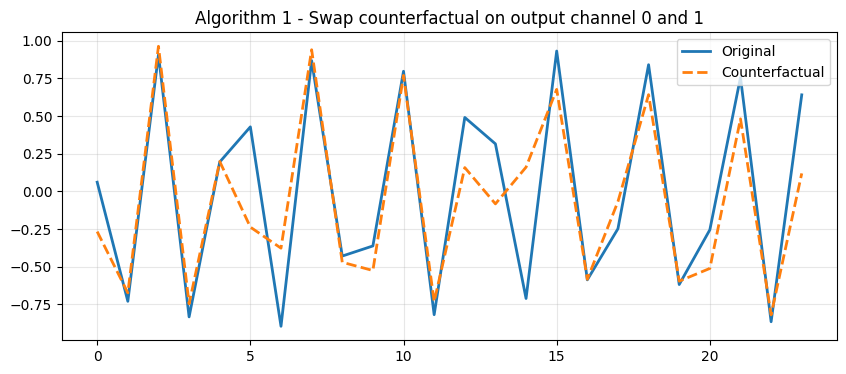

In [ ]:
plot_counterfactual_comparison(
    x_orig,
    x_cf,
    dim_idx=4,
    title="Algorithm 1 - Swap counterfactual on output channel 0 and 1",
)

Before comparing `z_orig` and `z_cf`, we first visualize a single point in the latent space in order to assess how the representation reacts to the counterfactual transformation. In our case, the total difference between the original latent code and the counterfactual one is approximately $37$, which is relatively large. This means that even a small targeted change in the generated output can induce a substantial displacement in latent space. Such a behavior suggests that the latent structure is not very strong, since a local semantic modification does not remain local in the representation space.

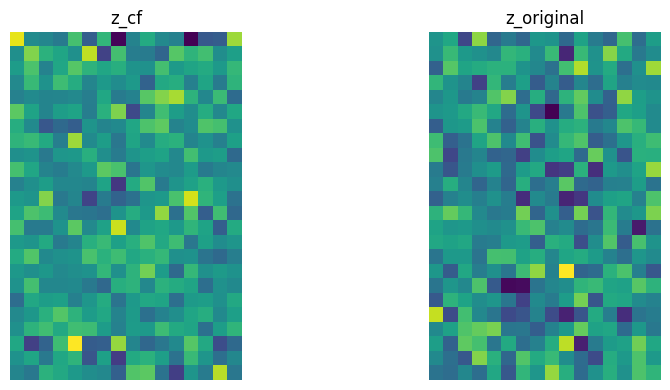

Mean: 37.12683868408203


In [ ]:
z_cf_numpy = z_cf.detach().cpu().numpy().squeeze(0)
z_origin_numpy = z_orig.detach().cpu().numpy().squeeze(0)

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].imshow(z_cf_numpy)
axs[0].set_title("z_cf")
axs[0].axis("off")

axs[1].imshow(z_origin_numpy)
axs[1].set_title("z_original")
axs[1].axis("off")

plt.tight_layout()
plt.show()

mean_error = (z_orig - z_cf).pow(2).mean()

print("Mean:", mean_error.item())

### Sobol sensitivity

We use Sobol' indices to perform a global sensitivity analysis of the latent variables and quantify their influence on the generated time series.

Let $Y = f(Z_1, \dots, Z_d)$ be a scalar feature of the generated signal (e.g., mean, dominant frequency, or energy), where each $Z_j$ corresponds to a latent channel. The total variance can be decomposed as:

$$
\mathrm{Var}(Y) = \sum_{i=1}^d V_i + \sum_{i<j} V_{ij} + \cdots
$$

The first-order Sobol' index measures the direct contribution of a latent channel:

$$
S_i = \frac{\mathrm{Var}(\mathbb{E}[Y \mid Z_i])}{\mathrm{Var}(Y)}
$$

The total Sobol' index captures both direct and interaction effects:

$$
S_{T_i} = 1 - \frac{\mathrm{Var}(\mathbb{E}[Y \mid Z_{\sim i}])}{\mathrm{Var}(Y)}
$$

In our setting, each latent channel (across all time steps) is treated as a group variable, and the output $Y$ corresponds to a scalar feature computed on the generated time series.

Due to the stochastic nature of the diffusion process, Sobol' estimates are unstable across runs. To mitigate this, we average the indices over multiple independent generations.

We observe that most total Sobol' indices remain close to zero, indicating weak global sensitivity to individual latent channels. This suggests that the generation process relies on distributed and interaction-driven mechanisms rather than on single dominant latent dimensions.

In [ ]:
@torch.no_grad()
def compute_group_sobol_algorithm1(
    ldm_model,
    vae_model,
    seq_len: int,
    latent_dim: int,
    target_fn,
    n_samples: int = 256,
    T: float = 1.0,
    steps: int = 100,
    device="cuda",
):
    """
    Approximate first-order and total Sobol indices for latent channels.
    Groups = latent channels across all time steps.
    """
    A = torch.randn(n_samples, seq_len, latent_dim, device=device)
    B = torch.randn(n_samples, seq_len, latent_dim, device=device)

    YA = target_fn(
        sample_algorithm1_ldm_differentiable(ldm_model, vae_model, A, T=T, steps=steps)
    )
    YB = target_fn(
        sample_algorithm1_ldm_differentiable(ldm_model, vae_model, B, T=T, steps=steps)
    )

    var_y = YA.var(unbiased=False) + 1e-8

    first_order = []
    total_order = []

    for j in range(latent_dim):
        ABj = A.clone()
        ABj[:, :, j] = B[:, :, j]

        YABj = target_fn(
            sample_algorithm1_ldm_differentiable(ldm_model, vae_model, ABj, T=T, steps=steps)
        )

        Sj = torch.mean(YB * (YABj - YA)) / var_y
        STj = 0.5 * torch.mean((YA - YABj) ** 2) / var_y

        first_order.append(Sj.item())
        total_order.append(STj.item())

    return np.array(first_order), np.array(total_order)

In [ ]:
def plot_sobol_indices(first_order, total_order, title="Sobol Sensitivity"):
    idx = np.arange(len(first_order))

    plt.figure(figsize=(10, 4))
    plt.bar(idx - 0.2, first_order, width=0.4, label="First-order")
    plt.bar(idx + 0.2, total_order, width=0.4, label="Total-order")
    plt.xlabel("Latent channel")
    plt.ylabel("Sensitivity")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [ ]:
def sobol_multiple_runs(
    n_runs,
    ldm_model,
    vae_model,
    seq_len,
    latent_dim,
    target_fn,
    n_samples=1024,
    T=1.0,
    steps=100,
    device="cuda",
):
    S1_all = []
    ST_all = []

    for _ in range(n_runs):
        S1, ST = compute_group_sobol_algorithm1(
            ldm_model=ldm_model,
            vae_model=vae_model,
            seq_len=seq_len,
            latent_dim=latent_dim,
            target_fn=target_fn,
            n_samples=n_samples,
            T=T,
            steps=steps,
            device=device,
        )

        S1_all.append(S1)
        ST_all.append(ST)

    S1_all = np.stack(S1_all)  # (n_runs, latent_dim)
    ST_all = np.stack(ST_all)

    S1_mean = S1_all.mean(axis=0)
    ST_mean = ST_all.mean(axis=0)

    S1_std = S1_all.std(axis=0)
    ST_std = ST_all.std(axis=0)

    return S1_mean, ST_mean, S1_std, ST_std

In [ ]:
target_fn = lambda x: target_fft_peak_on_dim(x, dim_idx=0)

S1_mean, ST_mean, S1_std, ST_std = sobol_multiple_runs(
    n_runs=30,
    ldm_model=ldm_model,
    vae_model=vae_model,
    seq_len=24,
    latent_dim=16,
    target_fn=target_fn,
    n_samples=1024,
    T=1.0,
    steps=100,
    device=device,
)

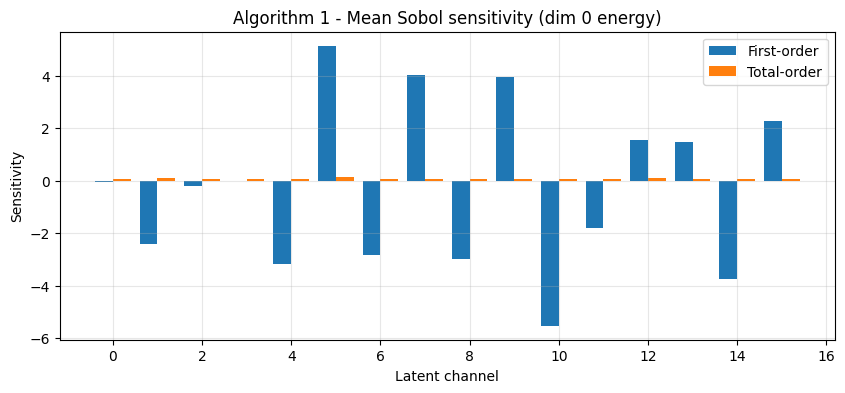

In [ ]:
plot_sobol_indices(
    S1_mean,
    ST_mean,
    title="Algorithm 1 - Mean Sobol sensitivity (dim 0 energy)",
)

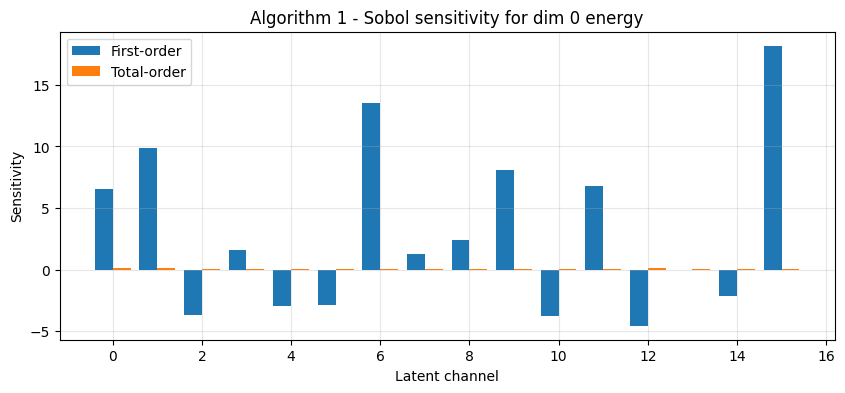

In [ ]:
target_fn = lambda x: target_energy_on_dim(x, dim_idx=0)

S1, ST = compute_group_sobol_algorithm1(
    ldm_model=ldm_model,
    vae_model=vae_model,
    seq_len=24,
    latent_dim=16,
    target_fn=target_fn,
    n_samples=1024,
    T=1.0,
    steps=100,
    device=device,
)

plot_sobol_indices(
    S1,
    ST,
    title="Algorithm 1 - Sobol sensitivity for dim 0 energy",
)

### Series perturbation (increment / decrement)

We analyze the sensitivity of the generative model by applying controlled perturbations to individual latent channels. Starting from an initial latent variable $z_0$, we modify a single channel $j$ by adding or subtracting a scalar offset:

$$
z^{(\delta)} = z_0 + \delta \cdot e_j
$$

where $e_j$ denotes the unit vector corresponding to latent channel $j$, and $\delta$ controls the magnitude of the perturbation.

The perturbed latent is then passed through the generative process:

$$
x^{(\delta)} = f(z^{(\delta)})
$$

By varying $\delta$ over a range of positive and negative values, we observe how incremental and decremental changes in a single latent channel affect the generated time series.

In practice, increasing perturbations along certain channels leads to progressive distortions or collapse of the generated signals, indicating strong sensitivity along these directions in latent space. Conversely, small perturbations often result in smooth variations of the output, suggesting local continuity of the generative mapping.

This analysis highlights which latent directions have a significant influence on the generation process and provides insight into the robustness and structure of the latent representation.

In [ ]:
def sample_algorithm1_ldm_differentiable(
    ldm_model,
    vae_model,
    z_init,
    T: float = 1.0,
    steps: int = 100,
    return_latents: bool = False,
):
    """
    Deterministic reverse sampler for explainability.

    Args:
        z_init: (B, seq_len, latent_dim)
    Returns:
        x_gen: (B, seq_len, input_dim)
        optionally latent trajectory
    """
    ldm_model.eval()
    vae_model.eval()

    z_t = z_init
    dt = T / steps

    trajectory = [z_t.detach().clone()] if return_latents else None

    for i in range(steps, 0, -1):
        t_val = i * dt
        t = torch.full((z_t.size(0),), t_val, device=z_t.device)

        eps_pred = ldm_model(z_t, t)
        score = -eps_pred / (t_val + 1e-5)

        z_t = z_t + 2.0 * t_val * score * dt

        if return_latents:
            trajectory.append(z_t.detach().clone())

    x_gen = vae_model.decode(z_t)

    if return_latents:
        return x_gen, trajectory
    return x_gen

In [ ]:
def target_mean_on_dim(x, dim_idx: int):
    return x[:, :, dim_idx].mean(dim=1)


def target_energy_on_dim(x, dim_idx: int):
    return (x[:, :, dim_idx] ** 2).mean(dim=1)


def target_value_at_time_dim(x, time_idx: int, dim_idx: int):
    return x[:, time_idx, dim_idx]


def target_fft_peak_on_dim(x, dim_idx: int):
    fft_mag = torch.fft.rfft(x[:, :, dim_idx], dim=1).abs()
    return fft_mag.max(dim=1).values

In [ ]:
seq_len = 24
latent_dim = 16

z_ref = torch.randn(1, seq_len, latent_dim, device=device)

with torch.no_grad():
    x_ref = sample_algorithm1_ldm_differentiable(
        ldm_model=ldm_model,
        vae_model=vae_model,
        z_init=z_ref,
        T=1.0,
        steps=100,
    )

print("Generated sample shape:", x_ref.shape)

Generated sample shape: torch.Size([1, 24, 5])


In [ ]:
def plot_generated_multivariate_sample(x, title="Generated Sample"):
    """
    x: (1, seq_len, input_dim) or (seq_len, input_dim)
    """
    if x.dim() == 3:
        x = x[0]

    x_np = x.detach().cpu().numpy()
    dim = x_np.shape[1]

    plt.figure(figsize=(10, 4))
    for d in range(dim):
        plt.plot(x_np[:, d], label=f"Dim {d}")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

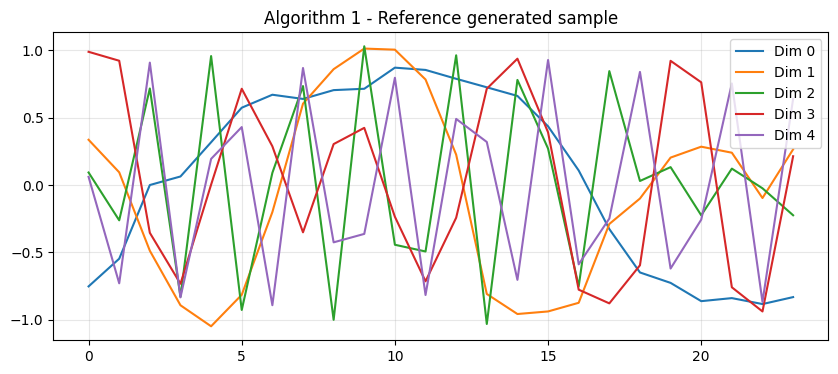

In [ ]:
plot_generated_multivariate_sample(
    x_ref,
    title="Algorithm 1 - Reference generated sample",
)

In [ ]:
@torch.no_grad()
def latent_traversal_algorithm1(
    ldm_model,
    vae_model,
    z_ref,
    latent_channel: int,
    values,
    time_mode: str = "all",
    time_idx: int = None,
    T: float = 1.0,
    steps: int = 100,
):
    """
    Traverse one latent channel.

    Args:
        latent_channel: which latent dimension to perturb
        values: iterable of values to add
        time_mode:
            - "all": perturb all time positions for that latent channel
            - "single": perturb only one time position
    """
    outputs = []

    for v in values:
        z_edit = z_ref.clone()

        if time_mode == "all":
            z_edit[:, :, latent_channel] += v
        elif time_mode == "single":
            assert time_idx is not None
            z_edit[:, time_idx, latent_channel] += v
        else:
            raise ValueError("time_mode must be 'all' or 'single'")

        x_edit = sample_algorithm1_ldm_differentiable(
            ldm_model=ldm_model,
            vae_model=vae_model,
            z_init=z_edit,
            T=T,
            steps=steps,
        )
        outputs.append(x_edit.detach().cpu())

    return outputs

In [ ]:
def plot_latent_traversal(outputs, values, dim_idx=0, title="Latent Traversal"):
    plt.figure(figsize=(10, 5))

    for out, v in zip(outputs, values):
        y = out[0, :, dim_idx].numpy()
        plt.plot(y, label=f"{v:+.2f}")

    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend(title="Delta")
    plt.show()

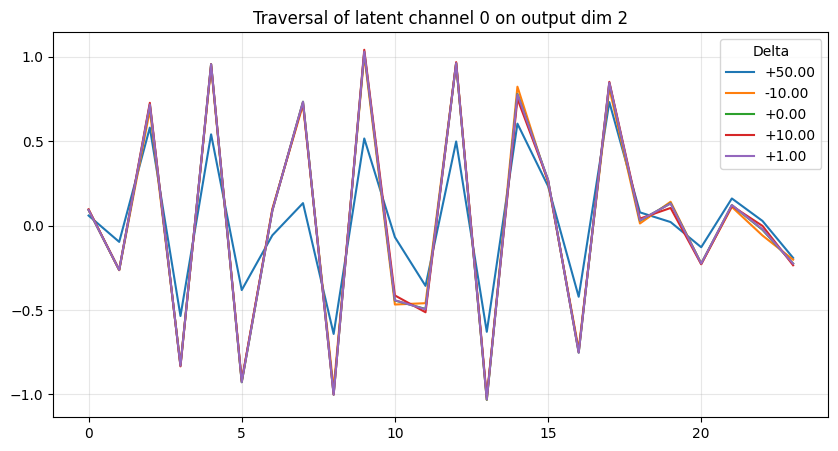

In [ ]:
values = [50.0, -10.0, 0.0, 10.0, 1.0]

traversal_outputs = latent_traversal_algorithm1(
    ldm_model=ldm_model,
    vae_model=vae_model,
    z_ref=z_ref,
    latent_channel=0,
    values=values,
    time_mode="all",
    T=1.0,
    steps=100,
)

plot_latent_traversal(
    traversal_outputs,
    values,
    dim_idx=2,
    title="Traversal of latent channel 0 on output dim 2",
)

### Latent ablation study

We further analyze the role of latent channels by performing ablation experiments. Starting from an initial latent variable $z_0$, we remove the contribution of a given channel $j$ by setting it to zero:

$$
z^{(-j)} = z_0, \quad z^{(-j)}_{:, j} = 0
$$

The modified latent is then passed through the generative process:

$$
x^{(-j)} = f(z^{(-j)})
$$

This procedure allows us to assess the importance of each latent channel by observing how its removal affects the generated time series.

In practice, we find that ablating individual channels often results in only minor changes in the generated signals, with the overall structure remaining largely preserved. This suggests that the model exhibits redundancy in its latent representation and does not rely on any single channel to produce coherent outputs.

These results are consistent with the Sobol' analysis and indicate that the generation process is distributed across multiple latent dimensions rather than controlled by isolated factors.

In [ ]:
def sample_algorithm1_ldm_deterministic(
    ldm_model,
    vae_model,
    z_init,
    T: float = 1.0,
    steps: int = 100,
):
    """
    Deterministic reverse sampler for analysis.
    z_init: (B, seq_len, latent_dim)
    returns: generated samples (B, seq_len, input_dim)
    """
    ldm_model.eval()
    vae_model.eval()

    z_t = z_init.clone()
    dt = T / steps

    for i in range(steps, 0, -1):
        t_val = i * dt
        t = torch.full((z_t.size(0),), t_val, device=z_t.device)

        eps_pred = ldm_model(z_t, t)
        score = -eps_pred / (t_val + 1e-5)

        z_t = z_t + 2.0 * t_val * score * dt

    return vae_model.decode(z_t)

In [ ]:
def ts_mean(x, dim_idx: int):
    return x[:, :, dim_idx].mean(dim=1)


def ts_energy(x, dim_idx: int):
    return (x[:, :, dim_idx] ** 2).mean(dim=1)


def ts_std(x, dim_idx: int):
    return x[:, :, dim_idx].std(dim=1)


def ts_fft_peak(x, dim_idx: int):
    fft_mag = torch.fft.rfft(x[:, :, dim_idx], dim=1).abs()
    return fft_mag.max(dim=1).values


def ts_dominant_freq_bin(x, dim_idx: int):
    fft_mag = torch.fft.rfft(x[:, :, dim_idx], dim=1).abs()
    return fft_mag.argmax(dim=1).float()

In [ ]:
seq_len = 24
latent_dim = 16

z_ref = torch.randn(1, seq_len, latent_dim, device=device)

with torch.no_grad():
    x_ref = sample_algorithm1_ldm_deterministic(
        ldm_model=ldm_model,
        vae_model=vae_model,
        z_init=z_ref,
        T=1.0,
        steps=100,
    )

print("Reference sample shape:", x_ref.shape)

Reference sample shape: torch.Size([1, 24, 5])


In [ ]:
def plot_multivariate_sample(x, title="Sample"):
    """
    x: (1, seq_len, input_dim) or (seq_len, input_dim)
    """
    if x.dim() == 3:
        x = x[0]

    x_np = x.detach().cpu().numpy()
    input_dim = x_np.shape[1]

    plt.figure(figsize=(10, 4))
    for d in range(input_dim):
        plt.plot(x_np[:, d], label=f"Dim {d}")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

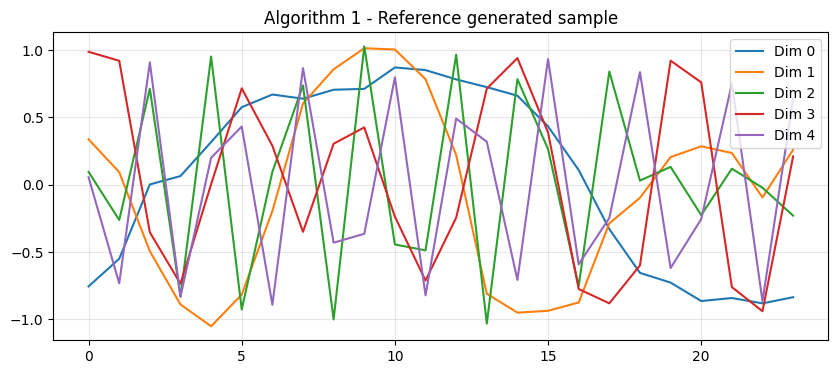

In [ ]:
plot_multivariate_sample(
    x_ref,
    title="Algorithm 1 - Reference generated sample",
)

In [ ]:
@torch.no_grad()
def ablate_latent_channel_algorithm1(
    ldm_model,
    vae_model,
    z_ref,
    channel_idx: int,
    mode: str = "zero",
    T: float = 1.0,
    steps: int = 100,
):
    """
    mode:
        - 'zero': set channel to 0
        - 'mean': replace channel by its temporal mean
    """
    z_edit = z_ref.clone()

    if mode == "zero":
        z_edit[:, :, channel_idx] = 0.0
        for i in range(0, 16):
            z_edit[:, :, i] = 0.0

    elif mode == "mean":
        channel_mean = z_edit[:, :, channel_idx].mean(dim=1, keepdim=True)
        z_edit[:, :, channel_idx] = channel_mean
    else:
        raise ValueError("mode must be 'zero' or 'mean'")

    x_edit = sample_algorithm1_ldm_deterministic(
        ldm_model=ldm_model,
        vae_model=vae_model,
        z_init=z_edit,
        T=T,
        steps=steps,
    )

    return x_edit

In [ ]:
def plot_ablation_comparison(x_ref, x_edit, dim_idx=0, title="Latent Ablation"):
    y_ref = x_ref[0, :, dim_idx].detach().cpu().numpy()
    y_edit = x_edit[0, :, dim_idx].detach().cpu().numpy()

    plt.figure(figsize=(10, 4))
    plt.plot(y_ref, label="Original", linewidth=2)
    plt.plot(y_edit, "--", label="Ablated", linewidth=2)
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

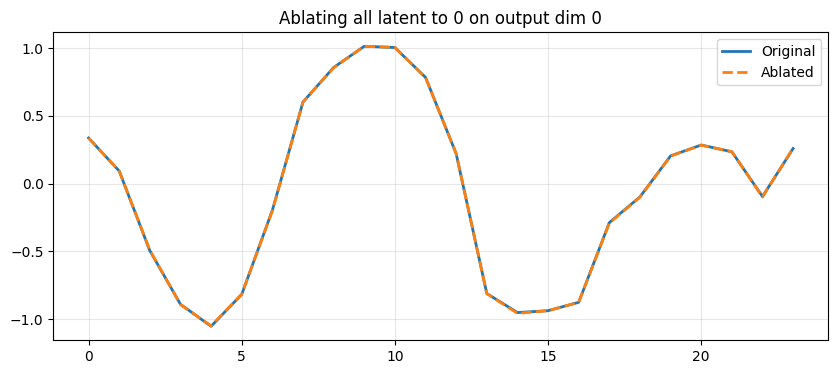

In [ ]:
x_ablate = ablate_latent_channel_algorithm1(
    ldm_model=ldm_model,
    vae_model=vae_model,
    z_ref=z_ref,
    channel_idx=0,
    mode="zero",
    T=1.0,
    steps=100,
)

plot_ablation_comparison(
    x_ref,
    x_ablate,
    dim_idx=1,
    title="Ablating all latent to 0 on output dim 0",
)

In [ ]:
@torch.no_grad()
def quantify_latent_ablation_effects(
    ldm_model,
    vae_model,
    z_ref,
    target_fn,
    mode: str = "zero",
    T: float = 1.0,
    steps: int = 100,
):
    """
    target_fn should return shape (B,)
    """
    _, _, latent_dim = z_ref.shape

    x_base = sample_algorithm1_ldm_deterministic(
        ldm_model=ldm_model,
        vae_model=vae_model,
        z_init=z_ref,
        T=T,
        steps=steps,
    )
    base_score = target_fn(x_base).item()

    effects = []

    for j in range(latent_dim):
        x_edit = ablate_latent_channel_algorithm1(
            ldm_model=ldm_model,
            vae_model=vae_model,
            z_ref=z_ref,
            channel_idx=j,
            mode=mode,
            T=T,
            steps=steps,
        )

        score_edit = target_fn(x_edit).item()
        effect = abs(score_edit - base_score)
        effects.append(effect)

    return base_score, np.array(effects)

In [ ]:
def plot_latent_ablation_effects(effects, title="Latent Ablation Effects"):
    plt.figure(figsize=(10, 4))
    plt.bar(np.arange(len(effects)), effects)
    plt.xlabel("Latent channel")
    plt.ylabel("Absolute effect")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.show()

Base energy: 0.4346467852592468


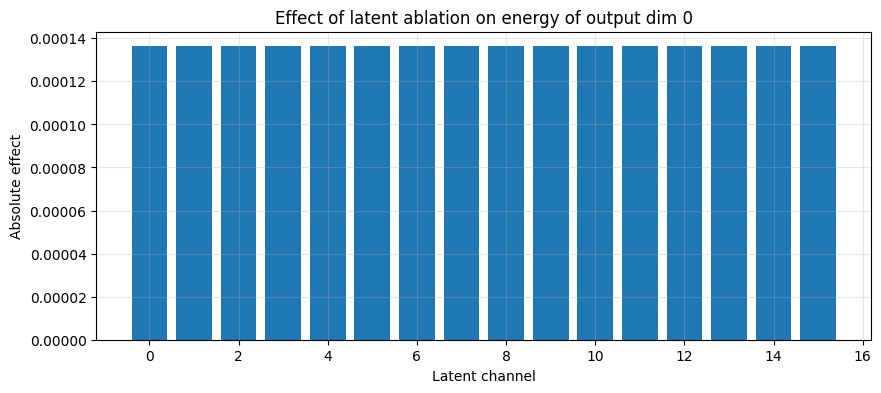

In [ ]:
target_fn = lambda x: ts_energy(x, dim_idx=0)

base_score, effects = quantify_latent_ablation_effects(
    ldm_model=ldm_model,
    vae_model=vae_model,
    z_ref=z_ref,
    target_fn=target_fn,
    mode="zero",
    T=1.0,
    steps=100,
)

print("Base energy:", base_score)

plot_latent_ablation_effects(
    effects,
    title="Effect of latent ablation on energy of output dim 0",
)

In [ ]:
@torch.no_grad()
def ablate_latent_group_algorithm1(
    ldm_model,
    vae_model,
    z_ref,
    channel_indices,
    mode="zero",
    T: float = 1.0,
    steps: int = 100,
):
    z_edit = z_ref.clone()

    if mode == "zero":
        z_edit[:, :, channel_indices] = 0.0
    elif mode == "noise":
        z_edit[:, :, channel_indices] = torch.randn_like(z_edit[:, :, channel_indices])
    else:
        raise ValueError("mode must be 'zero' or 'noise'")
    

    return sample_algorithm1_ldm_deterministic(
        ldm_model=ldm_model,
        vae_model=vae_model,
        z_init=z_edit,
        T=T,
        steps=steps,
    )

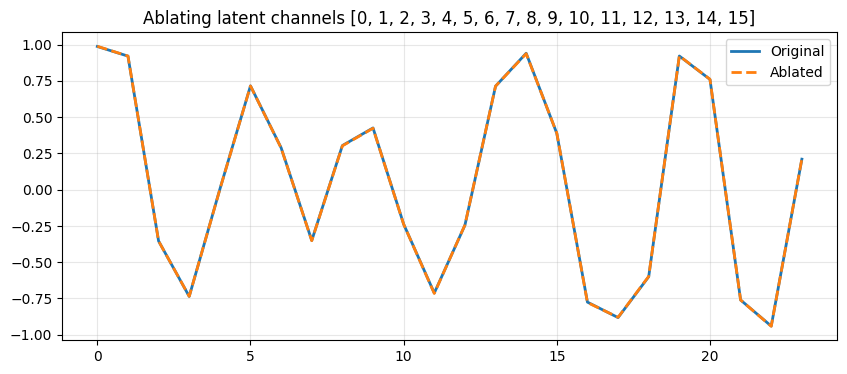

In [ ]:
x_group = ablate_latent_group_algorithm1(
    ldm_model=ldm_model,
    vae_model=vae_model,
    z_ref=z_ref,
    channel_indices=range(0, 16),
    mode="zero",
)

plot_ablation_comparison(
    x_ref,
    x_group,
    dim_idx=3,
    title=f"Ablating latent channels {list(range(0, 16))}",
)

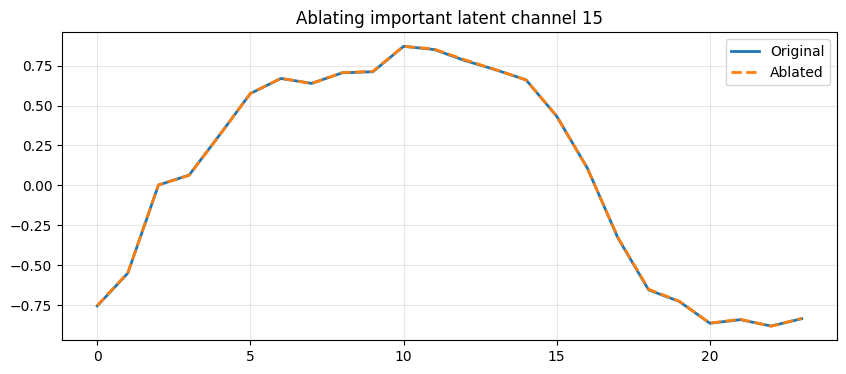

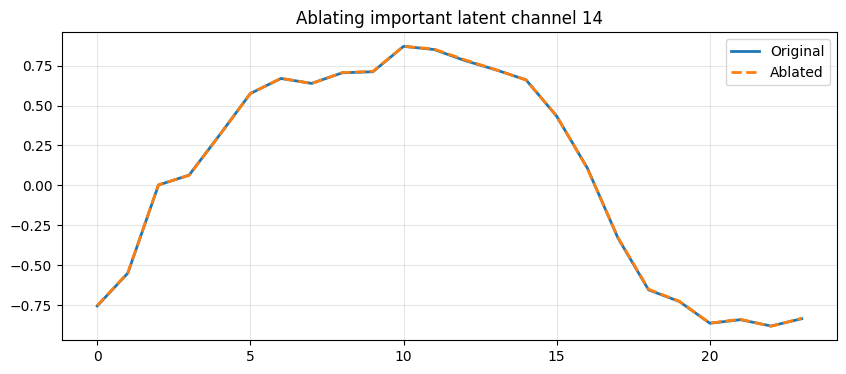

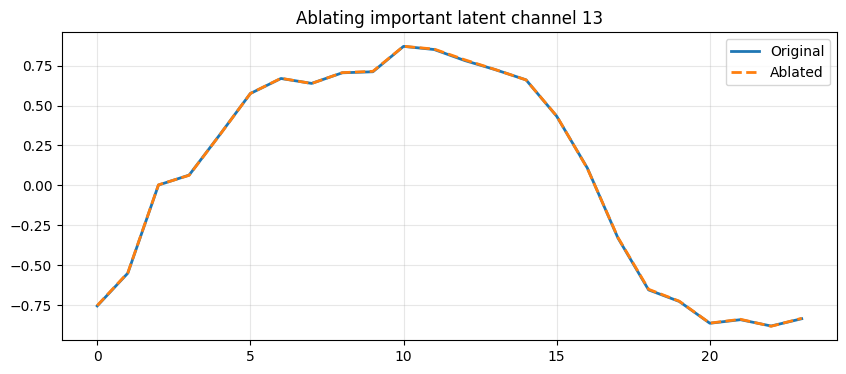

In [ ]:
top_idx = np.argsort(effects)[::-1][:3]

for ch in top_idx:
    x_edit = ablate_latent_channel_algorithm1(
        ldm_model=ldm_model,
        vae_model=vae_model,
        z_ref=z_ref,
        channel_idx=int(ch),
        mode="zero",
        T=1.0,
        steps=100,
    )

    plot_ablation_comparison(
        x_ref,
        x_edit,
        dim_idx=0,
        title=f"Ablating important latent channel {ch}",
    )